In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from pytorch_model_summary import summary

In [2]:
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode='train', transforms=None):
        digits = load_digits()
        if mode == 'train':
            self.data = digits.data[:1000].astype(np.float32)
        elif mode == 'val':
            self.data = digits.data[1000:1350].astype(np.float32)
        else:
            self.data = digits.data[1350:].astype(np.float32)

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

**Probability distributions**

In [3]:
PI = torch.from_numpy(np.asarray(np.pi))
EPS = 1.e-5

def log_categorical(x, p, num_classes=256, reduction=None, dim=None):
    x_one_hot = F.one_hot(x.long(), num_classes=num_classes)
    log_p = x_one_hot * torch.log(torch.clamp(p, EPS, 1. - EPS))
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

def log_bernoulli(x, p, reduction=None, dim=None):
    pp = torch.clamp(p, EPS, 1. - EPS)
    log_p = x * torch.log(pp) + (1. - x) * torch.log(1. - pp)
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

def log_normal_diag(x, mu, log_var, reduction=None, dim=None):
    D = x.shape[1]
    log_p = -0.5 * D * torch.log(2. * PI) - 0.5 * log_var - 0.5 * torch.exp(-log_var) * (x - mu)**2.
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p


def log_standard_normal(x, reduction=None, dim=None):
    D = x.shape[1]
    log_p = -0.5 * D * torch.log(2. * PI) - 0.5 * x**2.
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

**Encoder**

In [4]:
class Encoder(nn.Module):
    def __init__(self, encoder_net):
        super(Encoder, self).__init__()

        self.encoder = encoder_net

    @staticmethod
    def reparameterization(mu, log_var):
        std = torch.exp(0.5*log_var)

        eps = torch.randn_like(std)

        return mu + std * eps

    def encode(self, x):
        h_e = self.encoder(x)
        mu_e, log_var_e = torch.chunk(h_e, 2, dim=1)

        return mu_e, log_var_e

    def sample(self, x=None, mu_e=None, log_var_e=None):
        if (mu_e is None) and (log_var_e is None):
            mu_e, log_var_e = self.encode(x)
        else:
            if (mu_e is None) or (log_var_e is None):
                raise ValueError('mu and log-var can`t be None!')
        z = self.reparameterization(mu_e, log_var_e)
        return z

    def log_prob(self, x=None, mu_e=None, log_var_e=None, z=None):
        if x is not None:
            mu_e, log_var_e = self.encode(x)
            z = self.sample(mu_e=mu_e, log_var_e=log_var_e)
        else:
            if (mu_e is None) or (log_var_e is None) or (z is None):
                raise ValueError('mu, log-var and z can`t be None!')

        return log_normal_diag(z, mu_e, log_var_e)

    def forward(self, x, type='log_prob'):
        assert type in ['encode', 'log_prob'], 'Type could be either encode or log_prob'
        if type == 'log_prob':
            return self.log_prob(x)
        else:
            return self.sample(x)

**Decoder**

In [5]:
class Decoder(nn.Module):
    def __init__(self, decoder_net, distribution='categorical', num_vals=None):
        super(Decoder, self).__init__()

        self.decoder = decoder_net
        self.distribution = distribution
        self.num_vals=num_vals

    def decode(self, z):
        h_d = self.decoder(z)

        if self.distribution == 'categorical':
            b = h_d.shape[0]
            d = h_d.shape[1]//self.num_vals
            h_d = h_d.view(b, d, self.num_vals)
            mu_d = torch.softmax(h_d, 2)
            return [mu_d]

        elif self.distribution == 'bernoulli':
            mu_d = torch.sigmoid(h_d)
            return [mu_d]
        
        else:
            raise ValueError('Either `categorical` or `bernoulli`')

    def sample(self, z):
        outs = self.decode(z)

        if self.distribution == 'categorical':
            mu_d = outs[0]
            b = mu_d.shape[0]
            m = mu_d.shape[1]
            mu_d = mu_d.view(mu_d.shape[0], -1, self.num_vals)
            p = mu_d.view(-1, self.num_vals)
            x_new = torch.multinomial(p, num_samples=1).view(b, m)

        elif self.distribution == 'bernoulli':
            mu_d = outs[0]
            x_new = torch.bernoulli(mu_d)
        
        else:
            raise ValueError('Either `categorical` or `bernoulli`')

        return x_new

    def log_prob(self, x, z):
        outs = self.decode(z)

        if self.distribution == 'categorical':
            mu_d = outs[0]
            log_p = log_categorical(x, mu_d, num_classes=self.num_vals, reduction='sum', dim=-1).sum(-1)
            
        elif self.distribution == 'bernoulli':
            mu_d = outs[0]
            log_p = log_bernoulli(x, mu_d, reduction='sum', dim=-1)
            
        else:
            raise ValueError('Either `categorical` or `bernoulli`')

        return log_p

    def forward(self, z, x=None, type='log_prob'):
        assert type in ['decoder', 'log_prob'], 'Type could be either decode or log_prob'
        if type == 'log_prob':
            return self.log_prob(x, z)
        else:
            return self.sample(z)

**Prior**

In [6]:
class Prior(nn.Module):
    def __init__(self, L):
        super(Prior, self).__init__()
        self.L = L

    def sample(self, batch_size):
        z = torch.randn((batch_size, self.L))
        return z

    def log_prob(self, z):
        return log_standard_normal(z)

**Full VAE**

In [7]:
class VAE(nn.Module):
    def __init__(self, encoder_net, decoder_net, num_vals=256, L=16, likelihood_type='categorical'):
        super(VAE, self).__init__()

        print('VAE by JT.')

        self.encoder = Encoder(encoder_net=encoder_net)
        self.decoder = Decoder(distribution=likelihood_type, decoder_net=decoder_net, num_vals=num_vals)
        self.prior = Prior(L=L)

        self.num_vals = num_vals

        self.likelihood_type = likelihood_type

    def forward(self, x, reduction='avg'):
        # encoder
        mu_e, log_var_e = self.encoder.encode(x)
        z = self.encoder.sample(mu_e=mu_e, log_var_e=log_var_e)

        # ELBO
        RE = self.decoder.log_prob(x, z)
        KL = (self.prior.log_prob(z) - self.encoder.log_prob(mu_e=mu_e, log_var_e=log_var_e, z=z)).sum(-1)

        if reduction == 'sum':
            return -(RE + KL).sum()
        else:
            return -(RE + KL).mean()

    def sample(self, batch_size=64):
        z = self.prior.sample(batch_size=batch_size)
        return self.decoder.sample(z)

Auxiliary functions: training, evaluation, plotting

In [8]:
def load_model(path):
    return torch.load(path, map_location='cpu', weights_only=False)


def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        # load best performing model
        model_best = load_model(name + '.model')

    model_best.eval()
    loss = 0.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}')

    return loss


def samples_real(name, test_loader):
    # REAL-------
    num_x = 4
    num_y = 4
    x = next(iter(test_loader)).detach().numpy()

    fig, axes = plt.subplots(num_x, num_y, figsize=(8, 8))
    for i, ax in enumerate(axes.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def samples_generated(name, data_loader, extra_name=''):
    x = next(iter(data_loader)).detach().numpy()

    # GENERATIONS-------
    model_best = load_model(name + '.model')
    model_best.eval()

    num_x = 4
    num_y = 4
    x = model_best.sample(num_x * num_y)
    x = x.detach().numpy()

    fig, axes = plt.subplots(num_x, num_y, figsize=(8, 8))
    for i, ax in enumerate(axes.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def plot_curve(name, nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel('nll')
    plt.tight_layout()
    plt.show()


In [9]:
def training(name, max_patience, num_epochs, model, optimizer, training_loader, val_loader):
    nll_val = []
    best_nll = 1000.
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            if hasattr(model, 'dequantization'):
                if model.dequantization:
                    batch = batch + torch.rand(batch.shape)
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)  # save for plotting

        if e == 0:
            print('saved!')
            torch.save(model, name + '.model')
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                print('saved!')
                torch.save(model, name + '.model')
                best_nll = loss_val
                patience = 0

                samples_generated(name, val_loader, extra_name="_epoch_" + str(e))
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)

    return nll_val


Initialize dataloaders

In [10]:
train_data = Digits(mode='train')
val_data = Digits(mode='val')
test_data = Digits(mode='test')

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'vae'

Hyperparams

In [11]:
D = 64   # input dimension
L = 16  # number of latents
M = 256  # the number of neurons in scale (s) and translation (t) nets

lr = 1e-3 # learning rate
num_epochs = 1000 # max. number of epochs
max_patience = 20 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

Initialize VAE

In [12]:
likelihood_type = 'categorical'

if likelihood_type == 'categorical':
    num_vals = 17
elif likelihood_type == 'bernoulli':
    num_vals = 1

encoder = nn.Sequential(nn.Linear(D, M), nn.LeakyReLU(),
                        nn.Linear(M, M), nn.LeakyReLU(),
                        nn.Linear(M, 2 * L))

decoder = nn.Sequential(nn.Linear(L, M), nn.LeakyReLU(),
                        nn.Linear(M, M), nn.LeakyReLU(),
                        nn.Linear(M, num_vals * D))

prior = torch.distributions.MultivariateNormal(torch.zeros(L), torch.eye(L))
model = VAE(encoder_net=encoder, decoder_net=decoder, num_vals=num_vals, L=L, likelihood_type=likelihood_type)

# Print the summary (like in Keras)
print("ENCODER:\n", summary(encoder, torch.zeros(1, D), show_input=False, show_hierarchical=False))
print("\nDECODER:\n", summary(decoder, torch.zeros(1, L), show_input=False, show_hierarchical=False))

VAE by JT.
ENCODER:
 -----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1            [1, 256]          16,640          16,640
       LeakyReLU-2            [1, 256]               0               0
          Linear-3            [1, 256]          65,792          65,792
       LeakyReLU-4            [1, 256]               0               0
          Linear-5             [1, 32]           8,224           8,224
Total params: 90,656
Trainable params: 90,656
Non-trainable params: 0
-----------------------------------------------------------------------

DECODER:
 -----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1            [1, 256]           4,352           4,352
       LeakyReLU-2            [1, 256]               0               0
          Linear-3            [1, 256]     

In [13]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

Epoch: 0, val nll=126.77514299665178
saved!
Epoch: 1, val nll=113.55714285714286
saved!


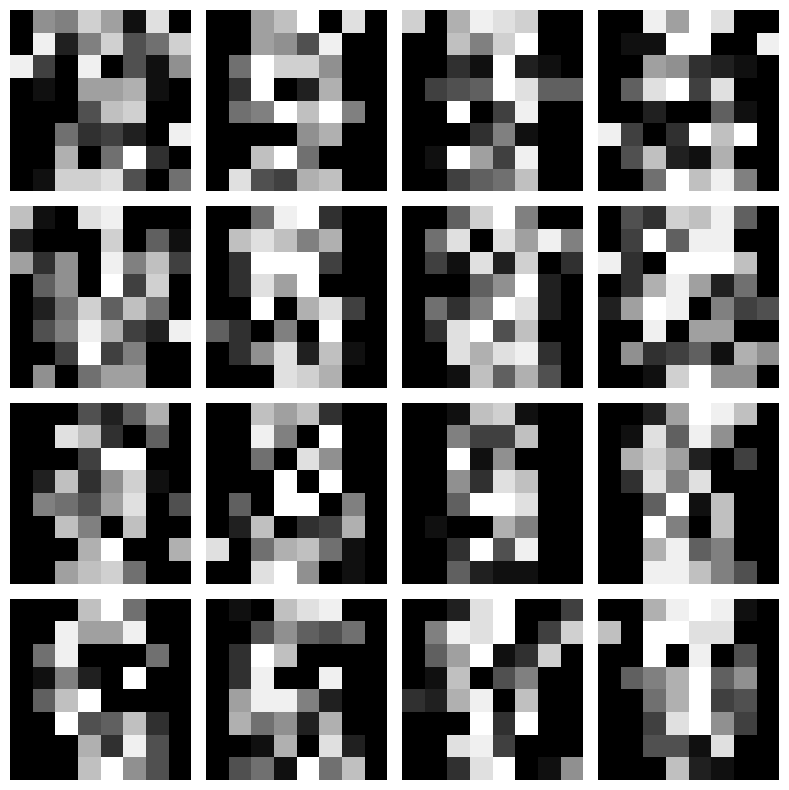

Epoch: 2, val nll=112.12432407924108
saved!


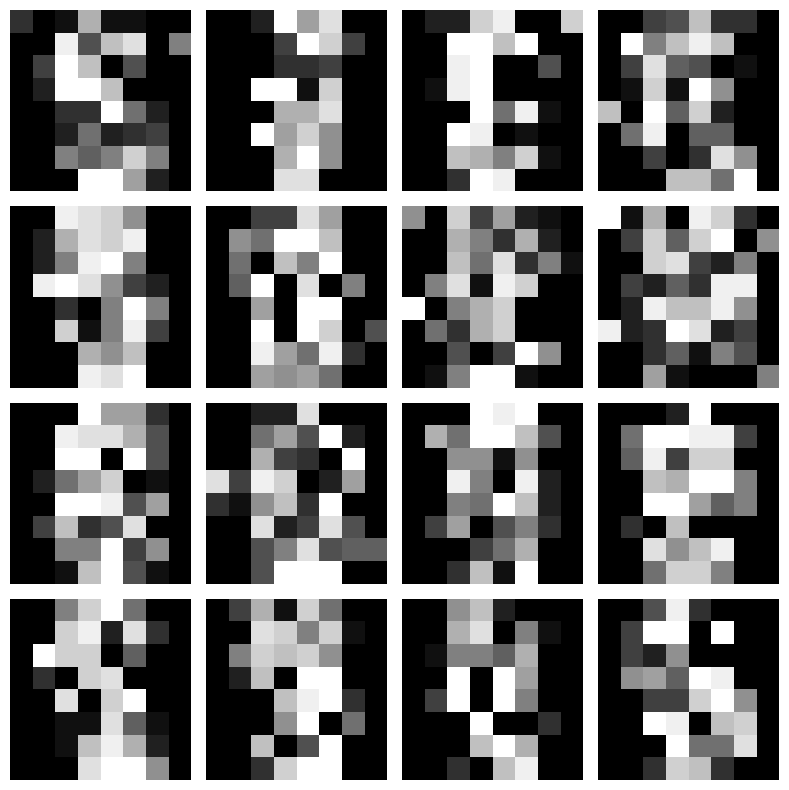

Epoch: 3, val nll=111.93883719308036
saved!


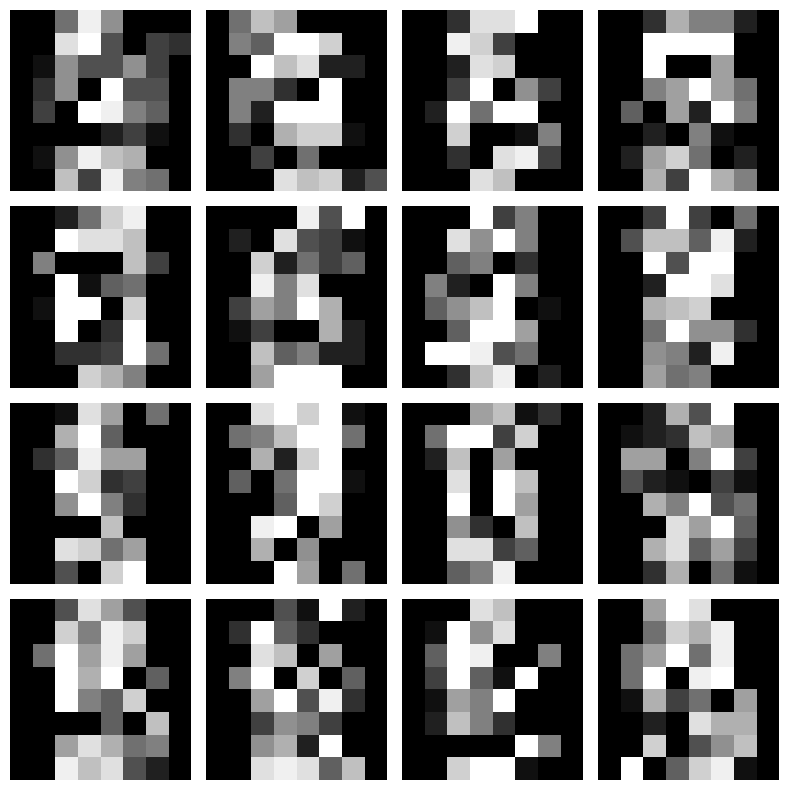

Epoch: 4, val nll=111.54914969308035
saved!


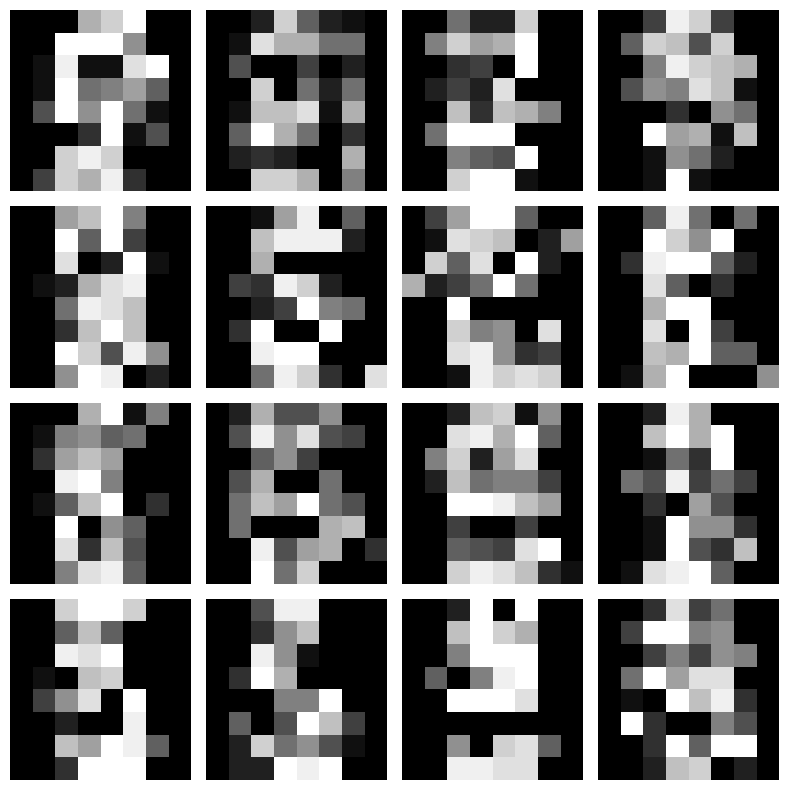

Epoch: 5, val nll=111.497880859375
saved!


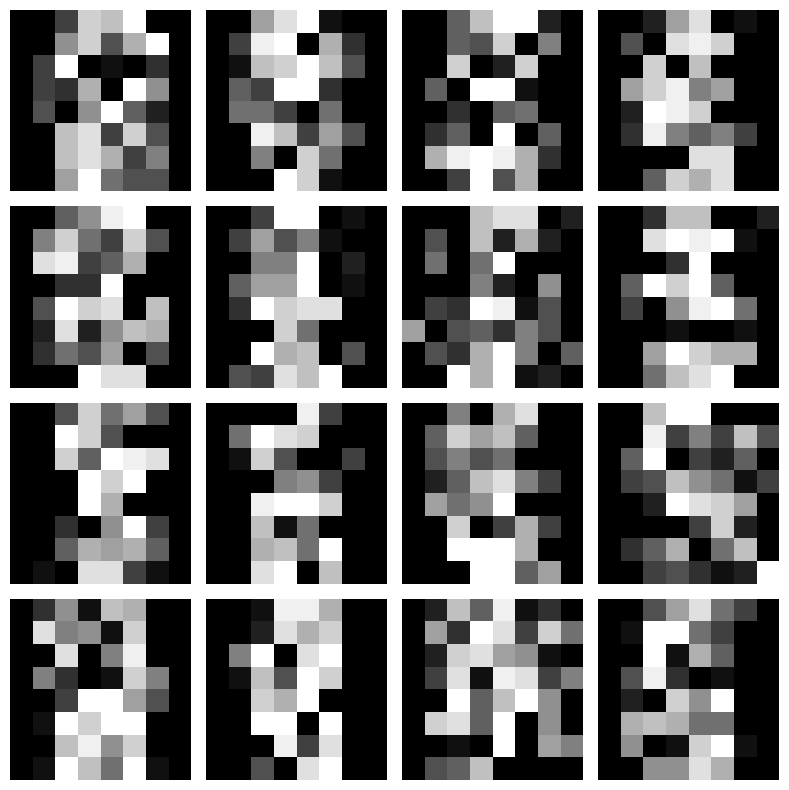

Epoch: 6, val nll=111.51134765625
Epoch: 7, val nll=111.50906040736608
Epoch: 8, val nll=111.37695940290179
saved!


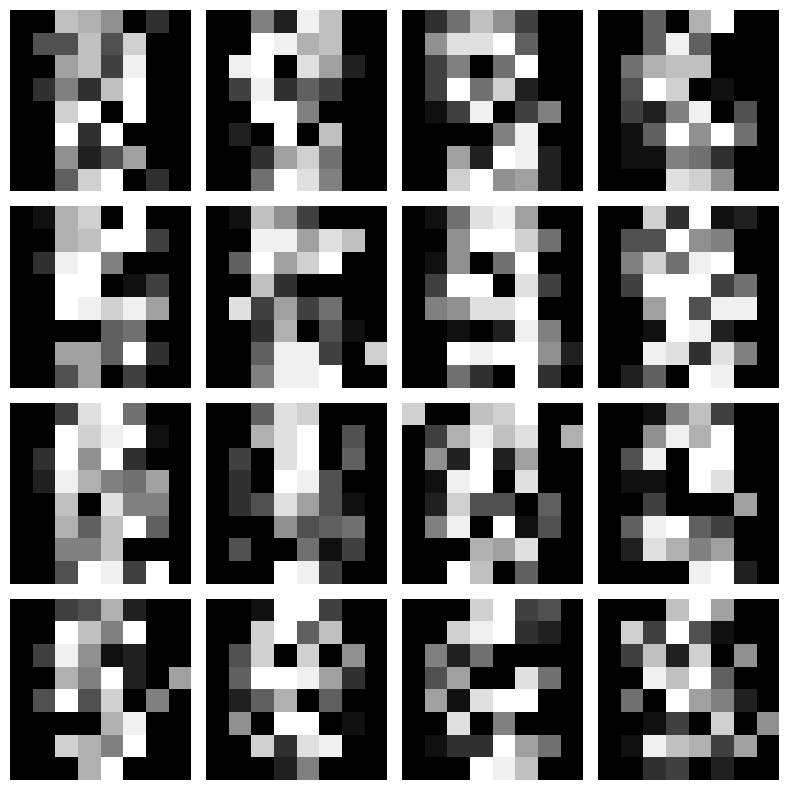

Epoch: 9, val nll=111.36966727120536
saved!


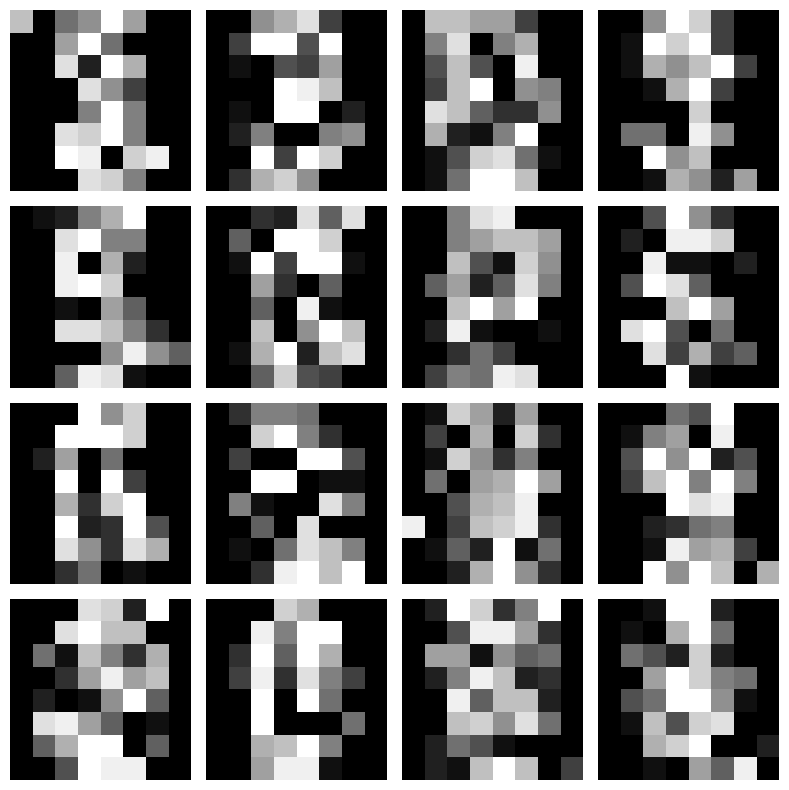

Epoch: 10, val nll=111.18599958147321
saved!


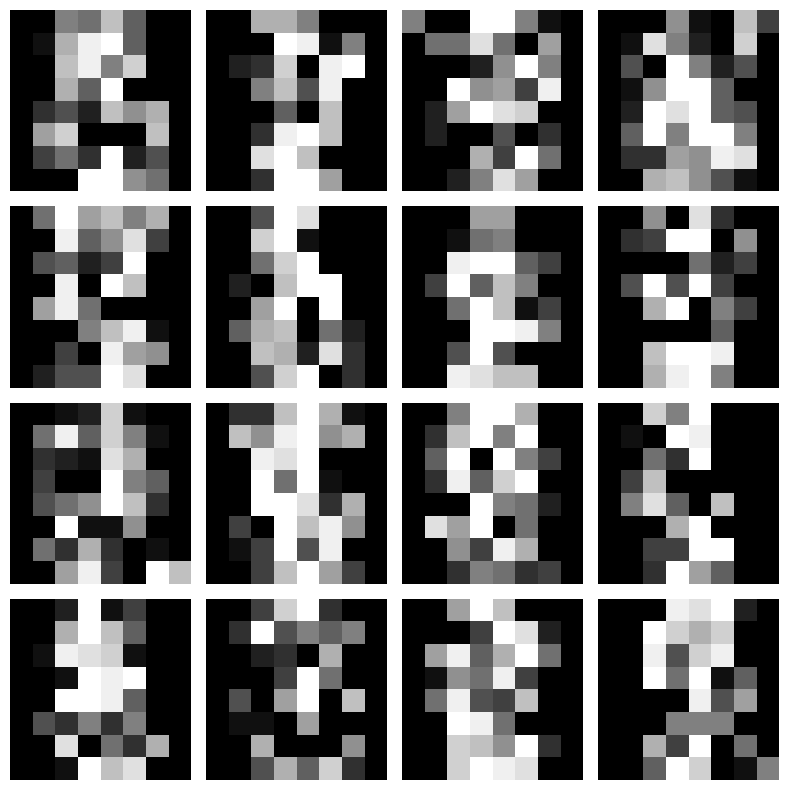

Epoch: 11, val nll=111.241240234375
Epoch: 12, val nll=111.24412806919644
Epoch: 13, val nll=111.10331124441964
saved!


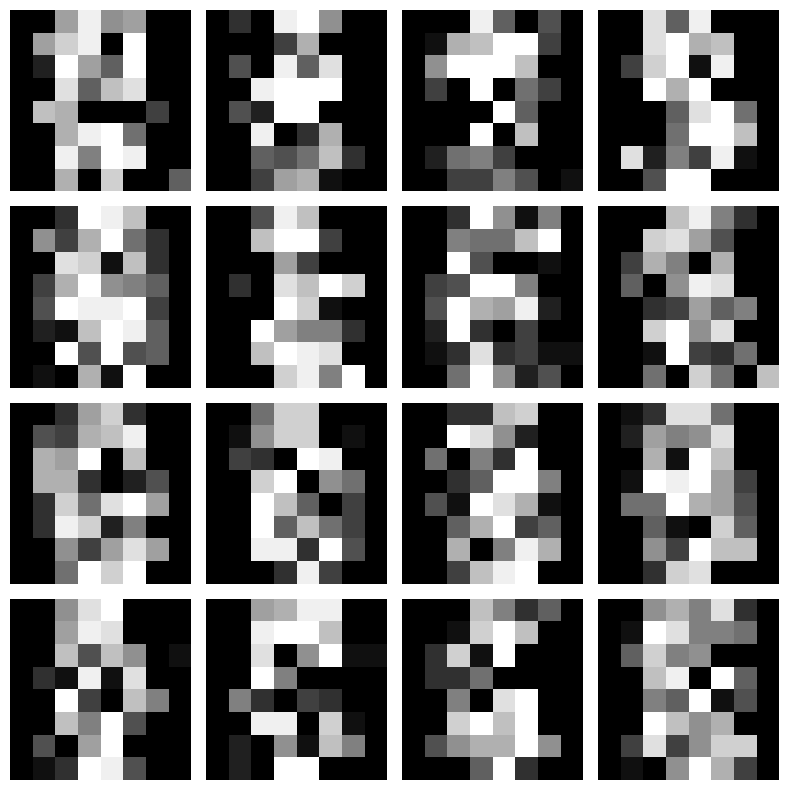

Epoch: 14, val nll=111.12474539620536
Epoch: 15, val nll=110.95118931361607
saved!


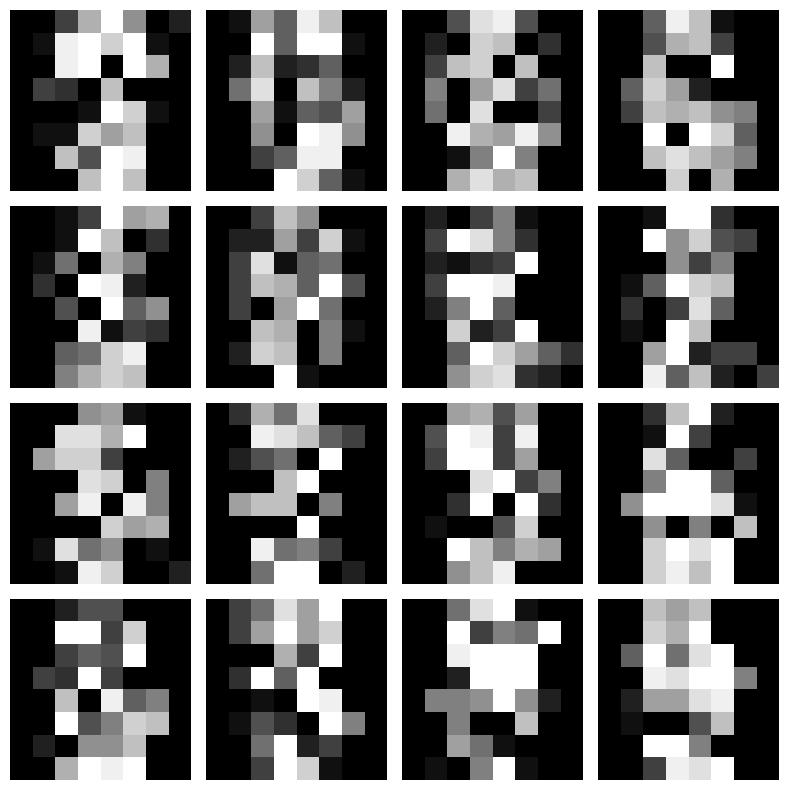

Epoch: 16, val nll=111.01235770089286
Epoch: 17, val nll=110.96202915736608
Epoch: 18, val nll=110.768154296875
saved!


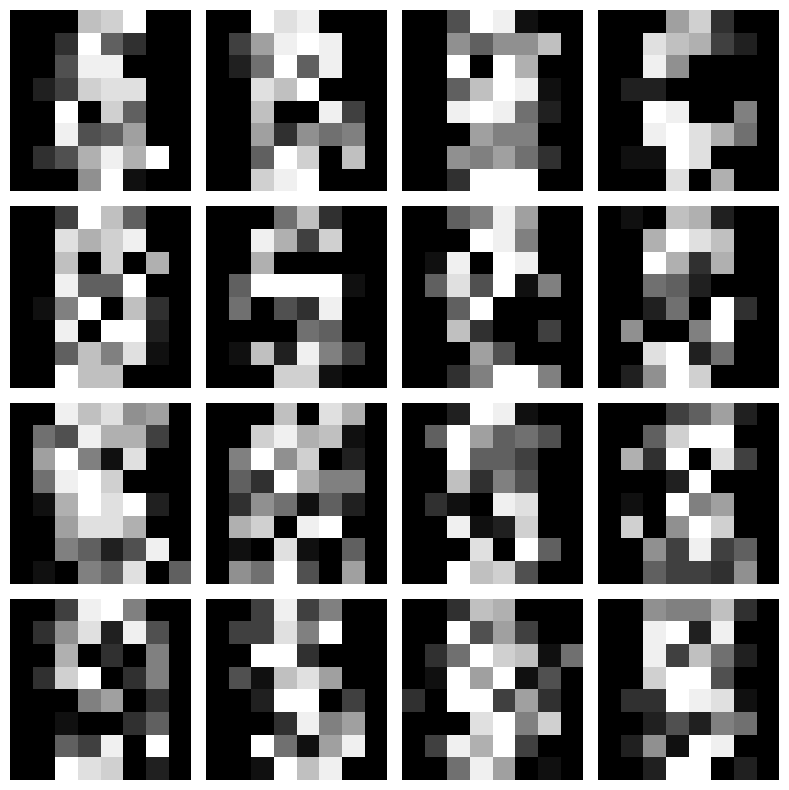

Epoch: 19, val nll=110.66991978236607
saved!


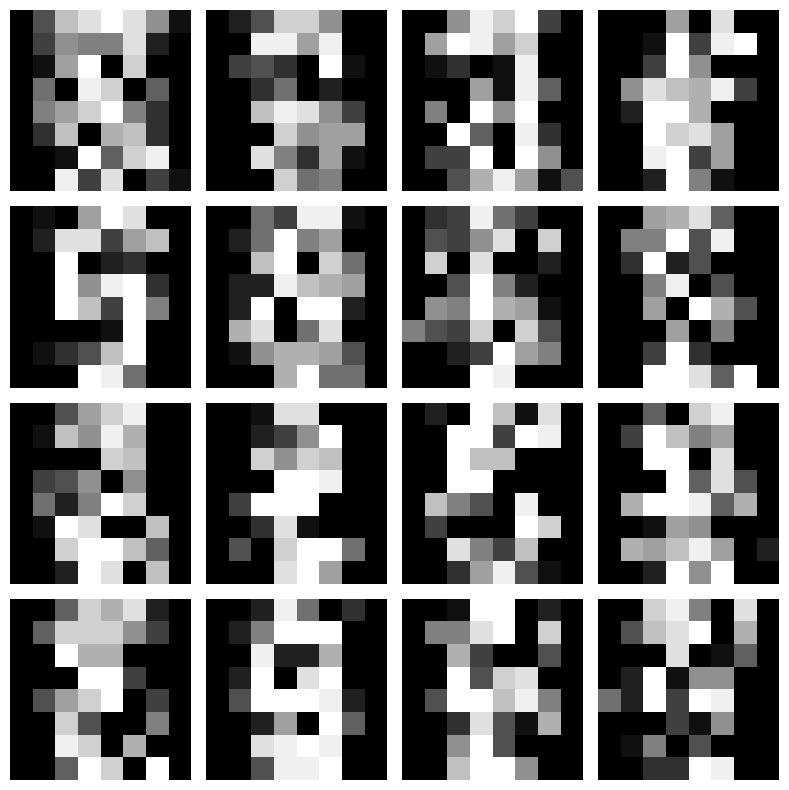

Epoch: 20, val nll=110.57927036830357
saved!


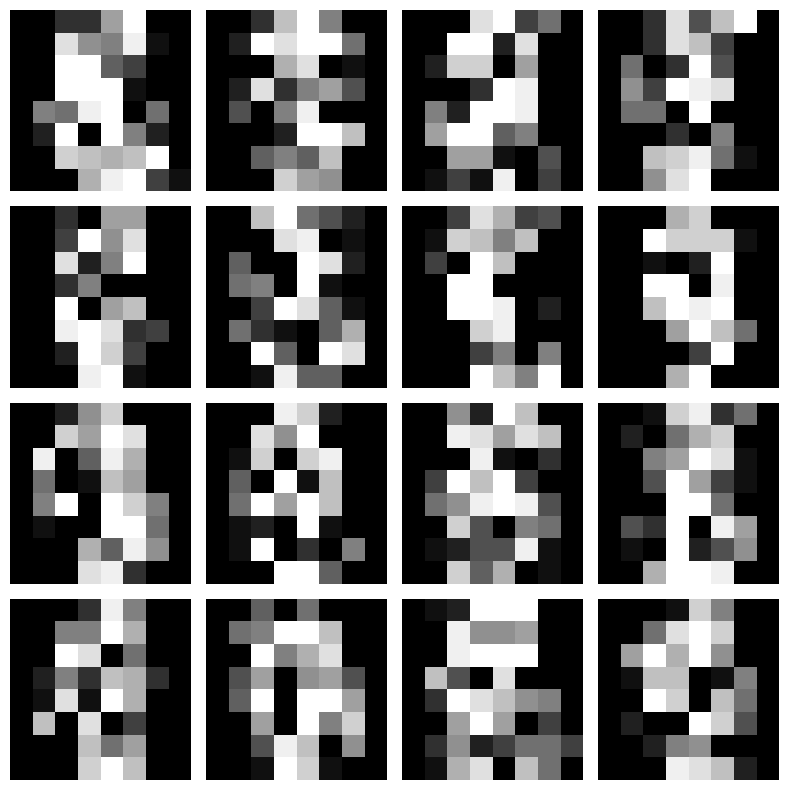

Epoch: 21, val nll=110.18196149553572
saved!


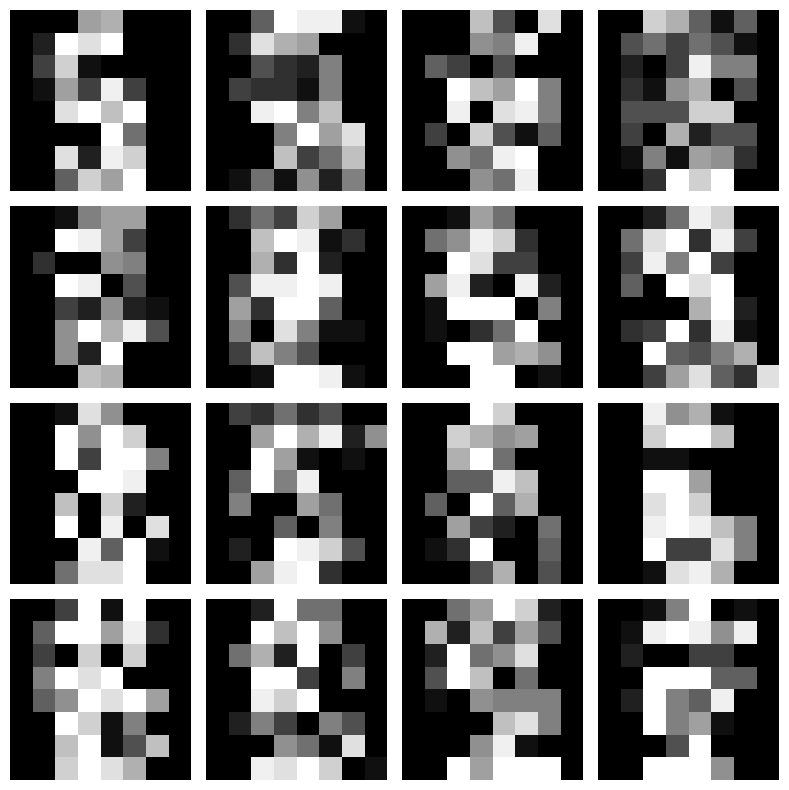

Epoch: 22, val nll=109.897177734375
saved!


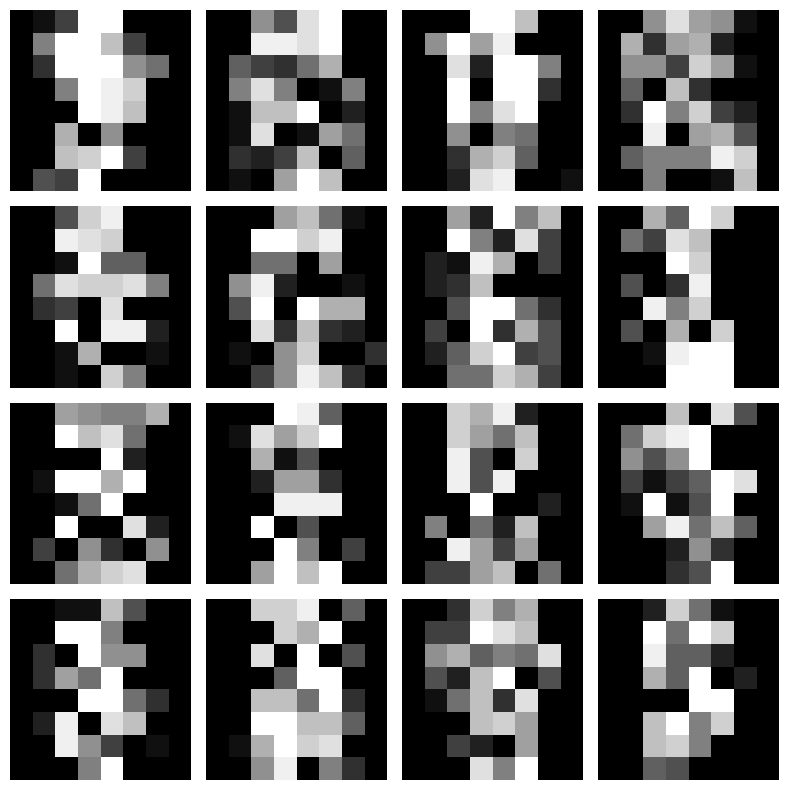

Epoch: 23, val nll=109.42147112165179
saved!


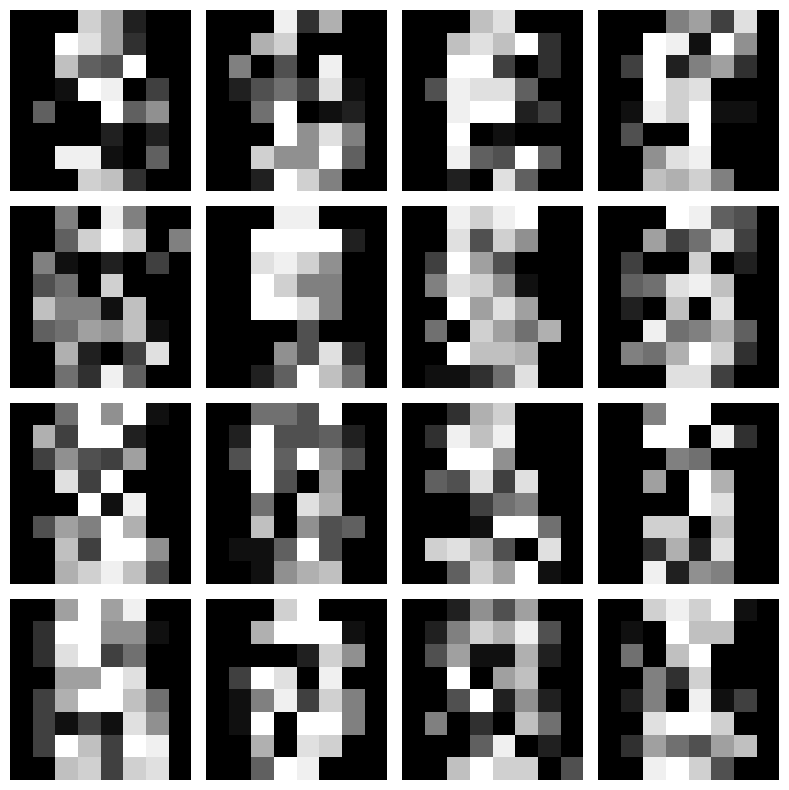

Epoch: 24, val nll=109.17909458705357
saved!


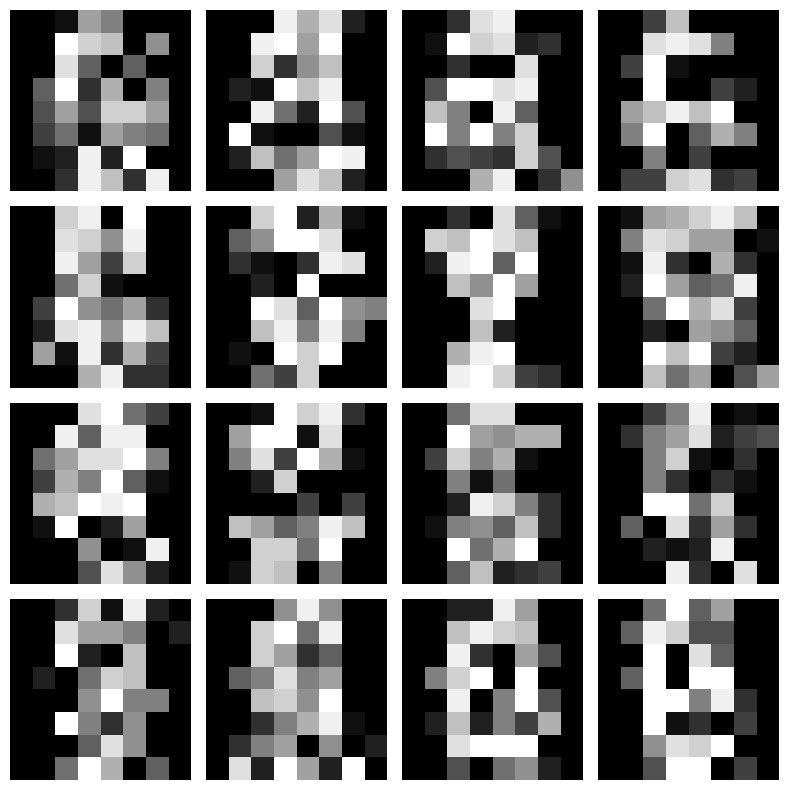

Epoch: 25, val nll=108.88933314732142
saved!


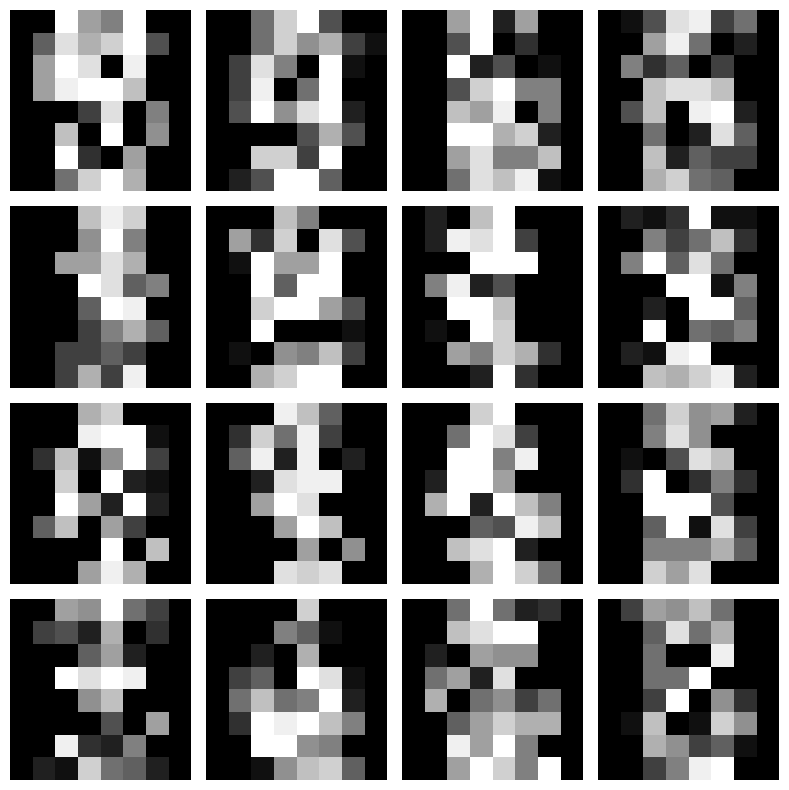

Epoch: 26, val nll=108.49709542410714
saved!


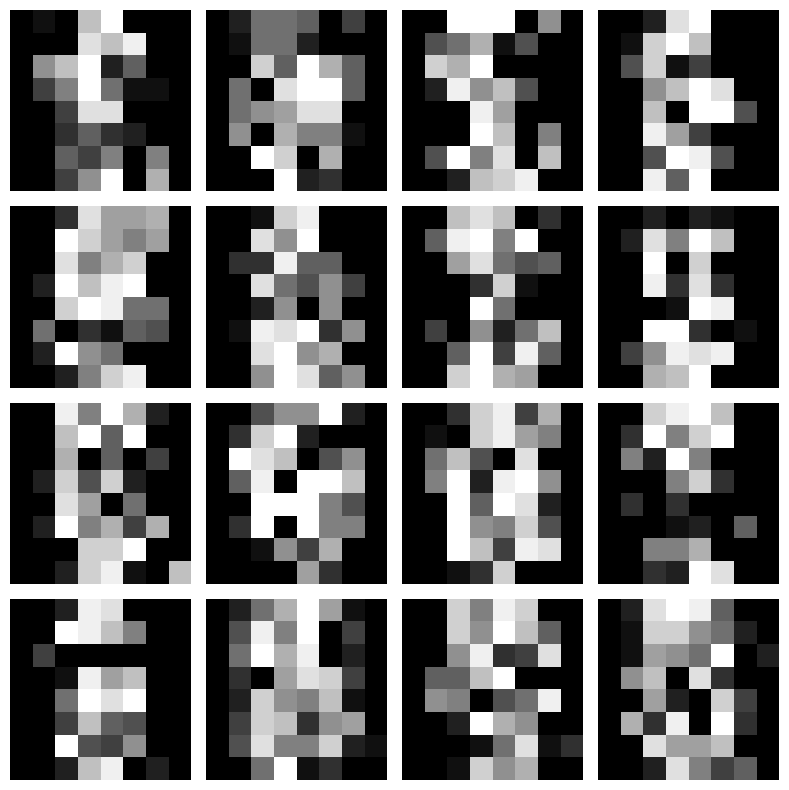

Epoch: 27, val nll=108.07586356026786
saved!


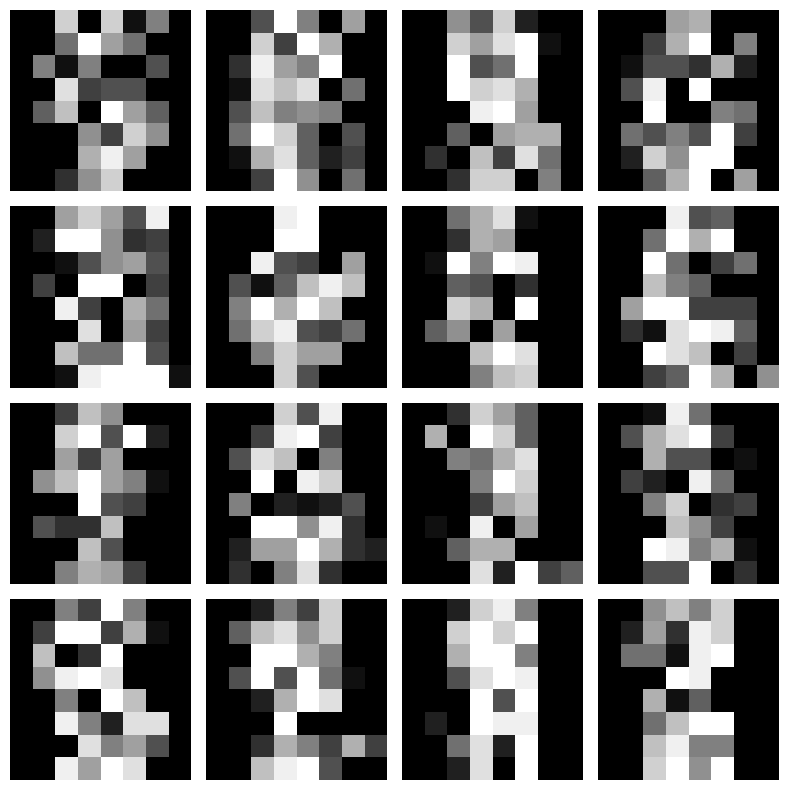

Epoch: 28, val nll=107.81244349888392
saved!


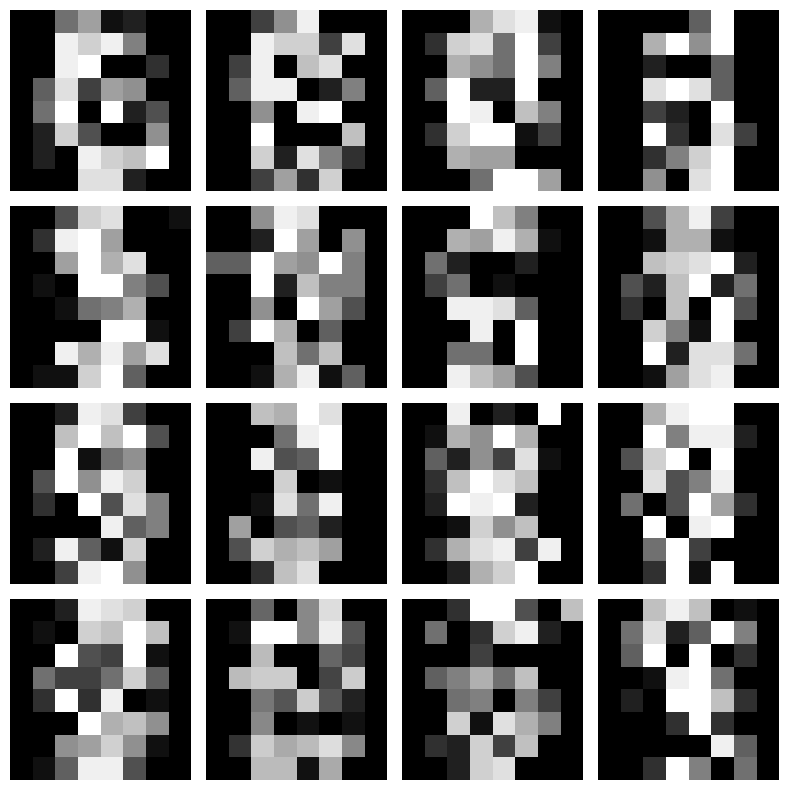

Epoch: 29, val nll=107.6100048828125
saved!


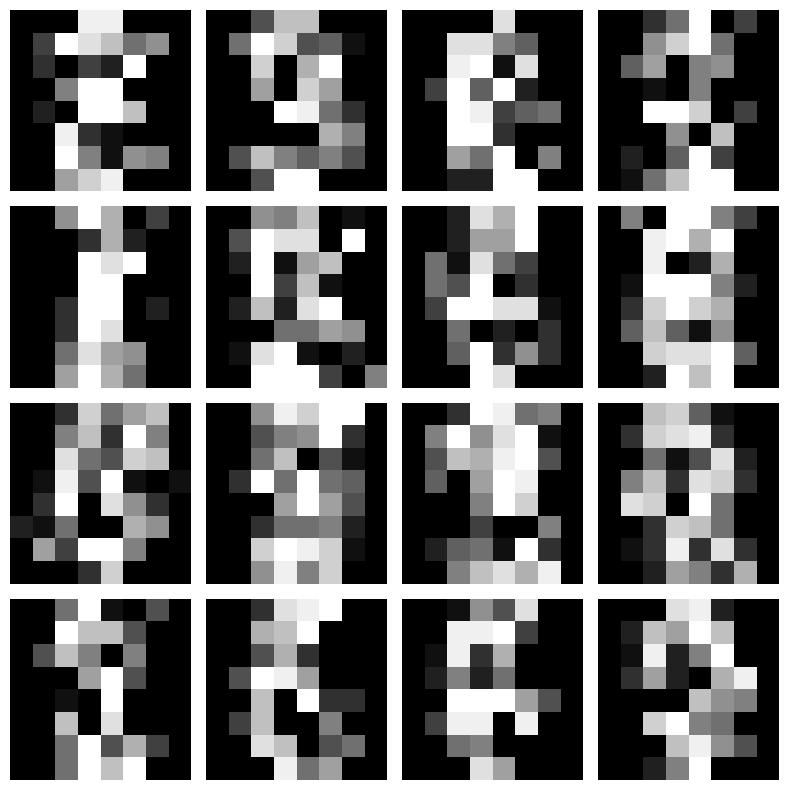

Epoch: 30, val nll=107.22595912388392
saved!


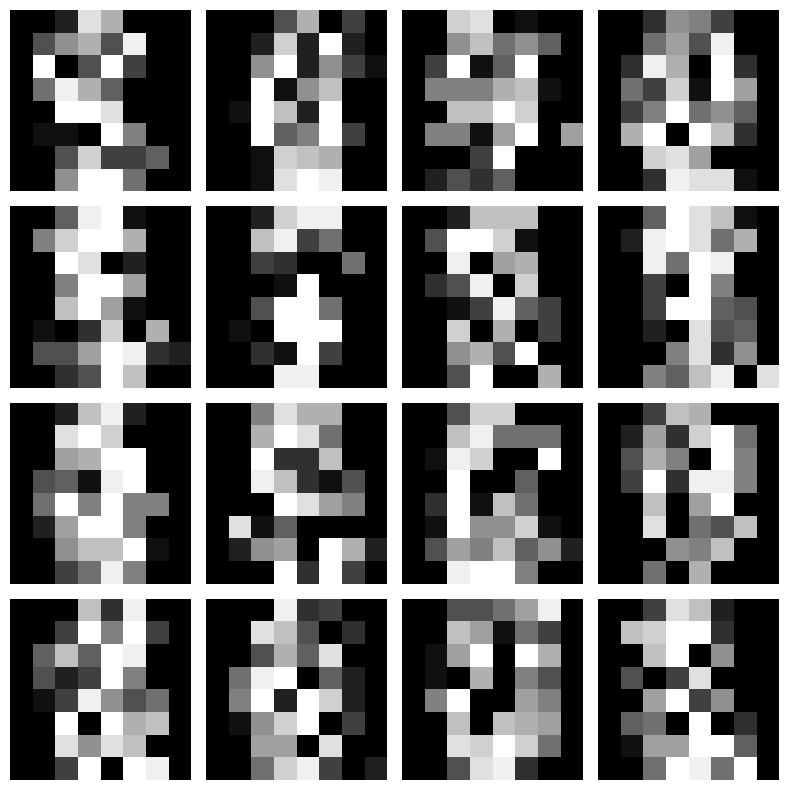

Epoch: 31, val nll=107.41416224888393
Epoch: 32, val nll=106.5086376953125
saved!


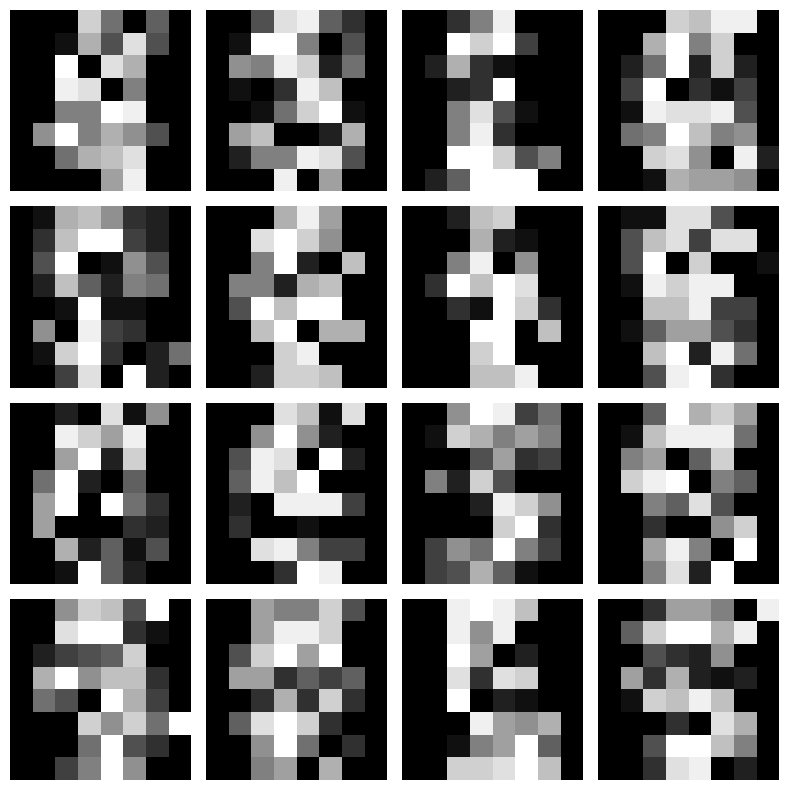

Epoch: 33, val nll=106.9493701171875
Epoch: 34, val nll=106.19286690848215
saved!


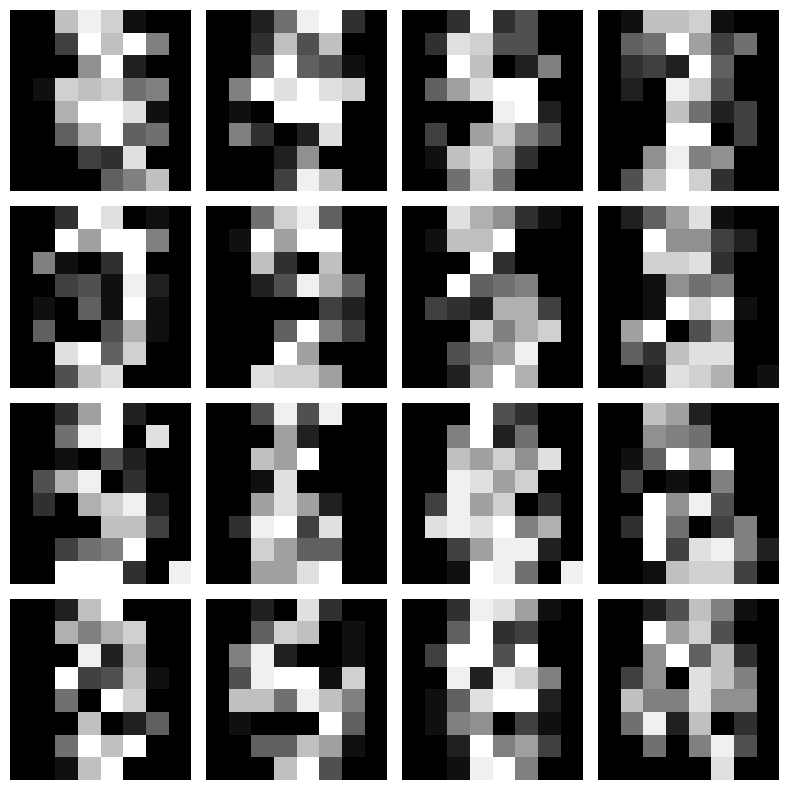

Epoch: 35, val nll=105.917939453125
saved!


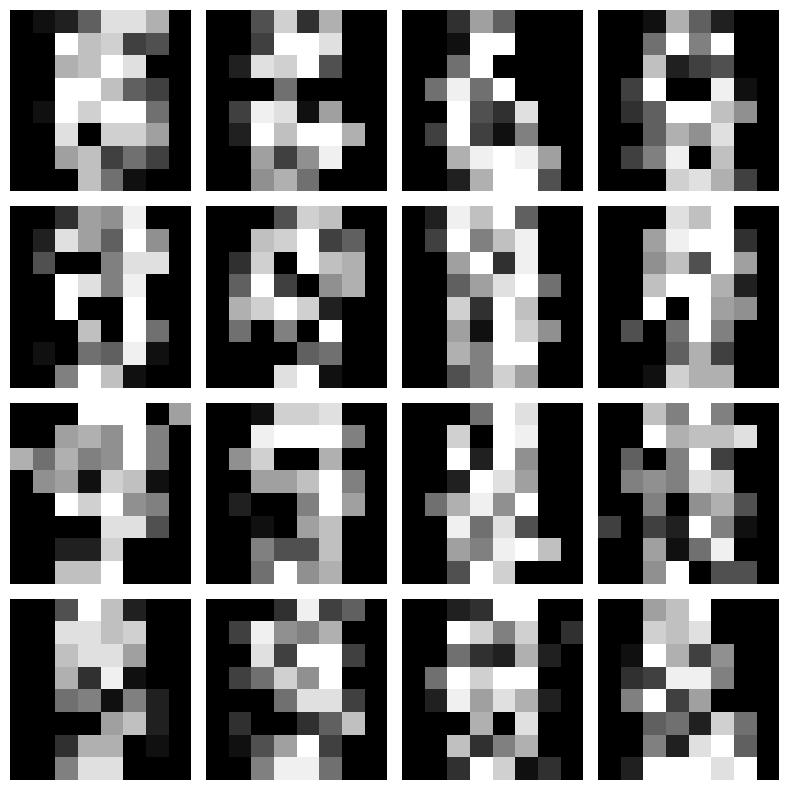

Epoch: 36, val nll=105.94709542410715
Epoch: 37, val nll=105.80606863839286
saved!


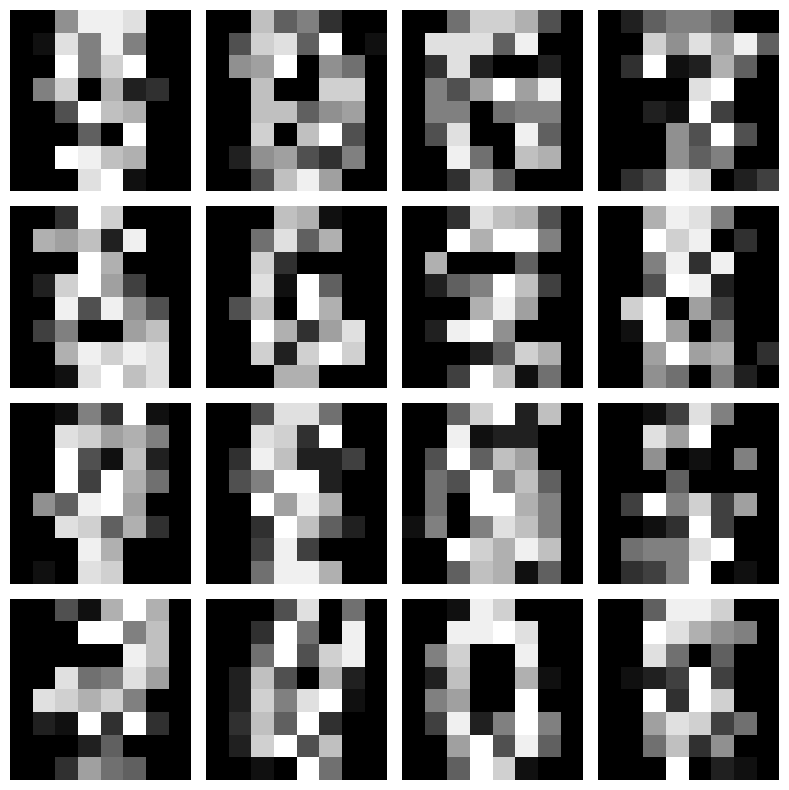

Epoch: 38, val nll=105.39552176339286
saved!


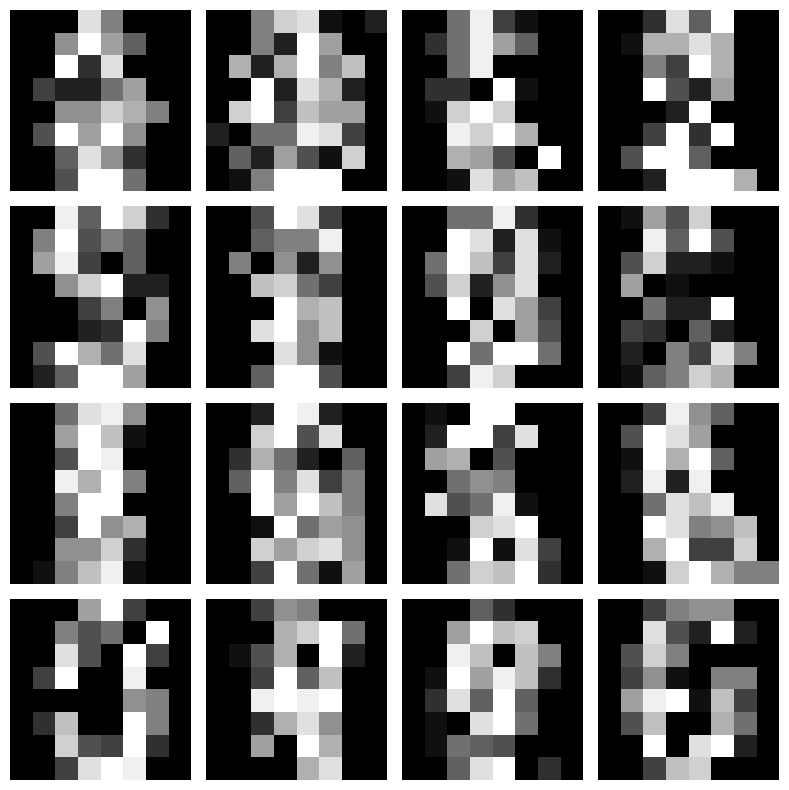

Epoch: 39, val nll=105.39334263392857
saved!


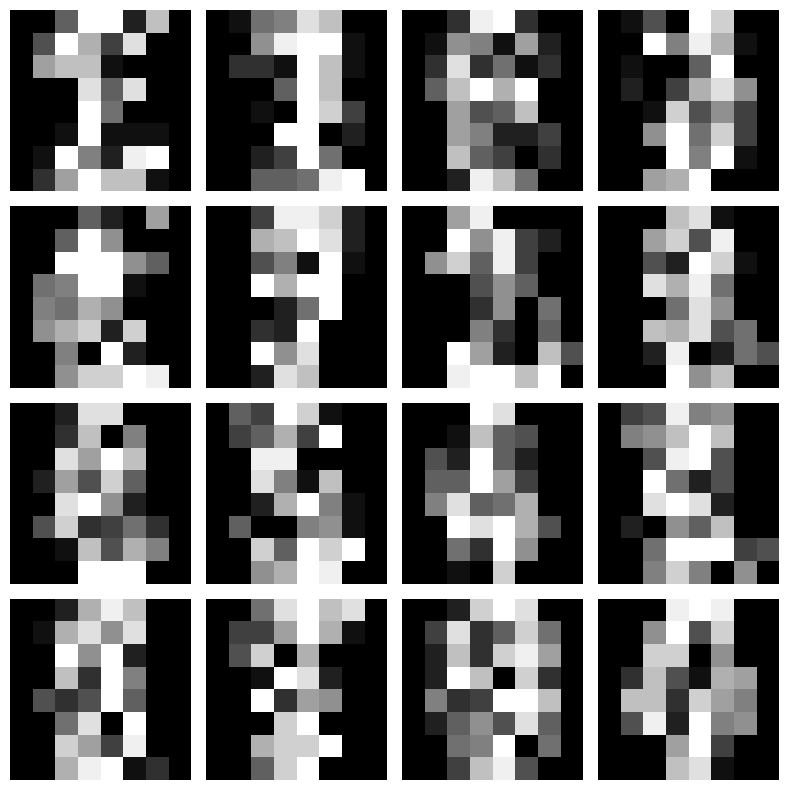

Epoch: 40, val nll=105.17367745535714
saved!


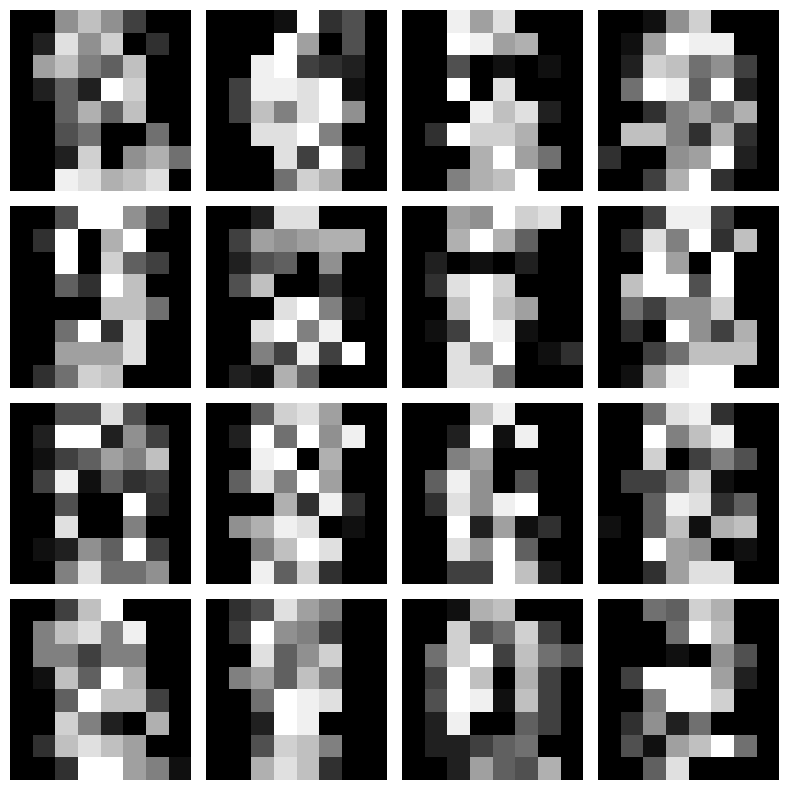

Epoch: 41, val nll=104.97030970982142
saved!


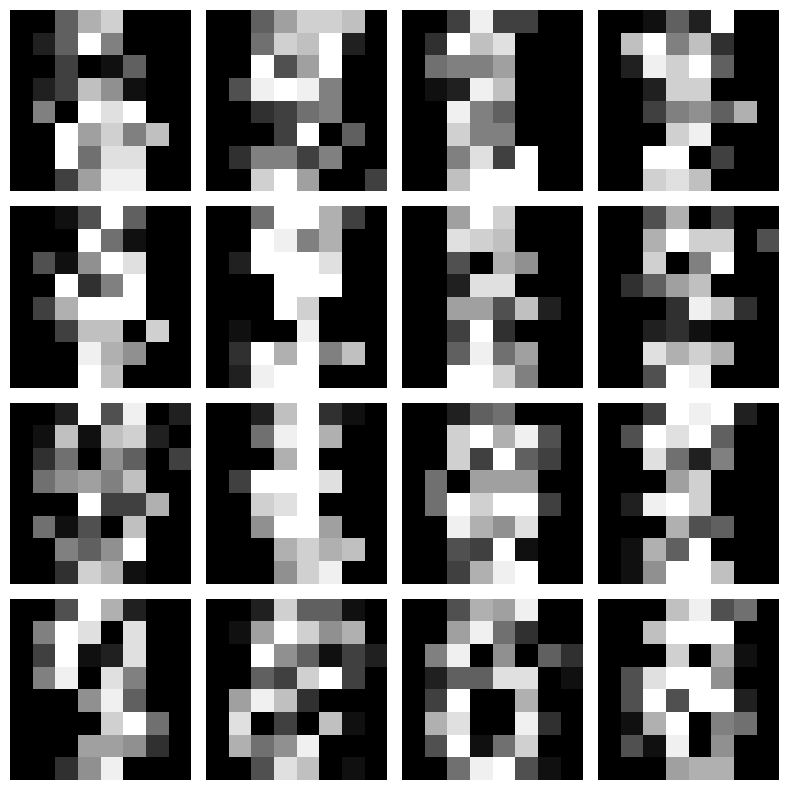

Epoch: 42, val nll=104.93045758928571
saved!


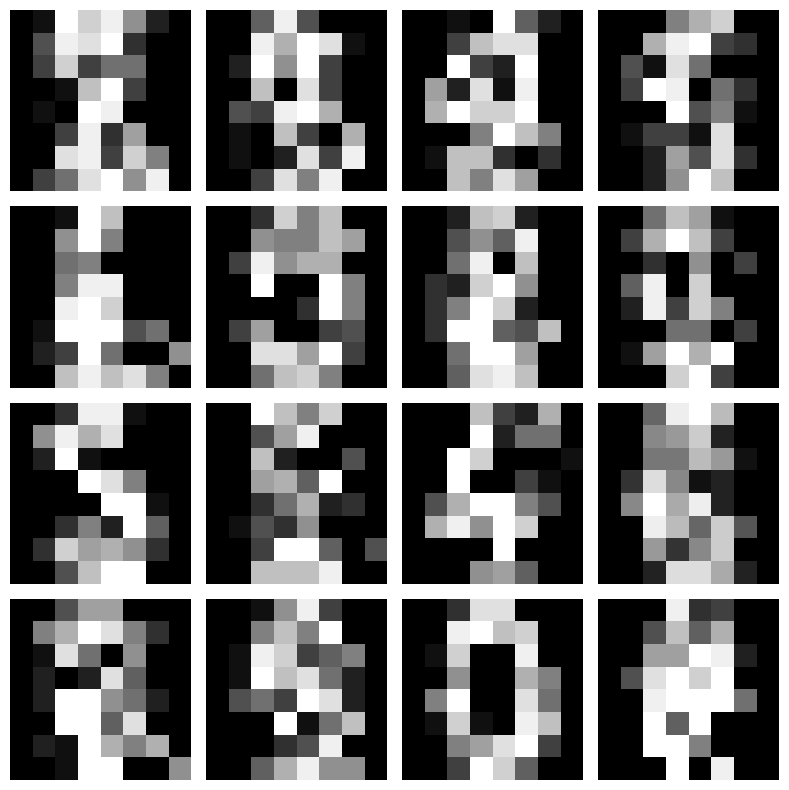

Epoch: 43, val nll=104.82390485491071
saved!


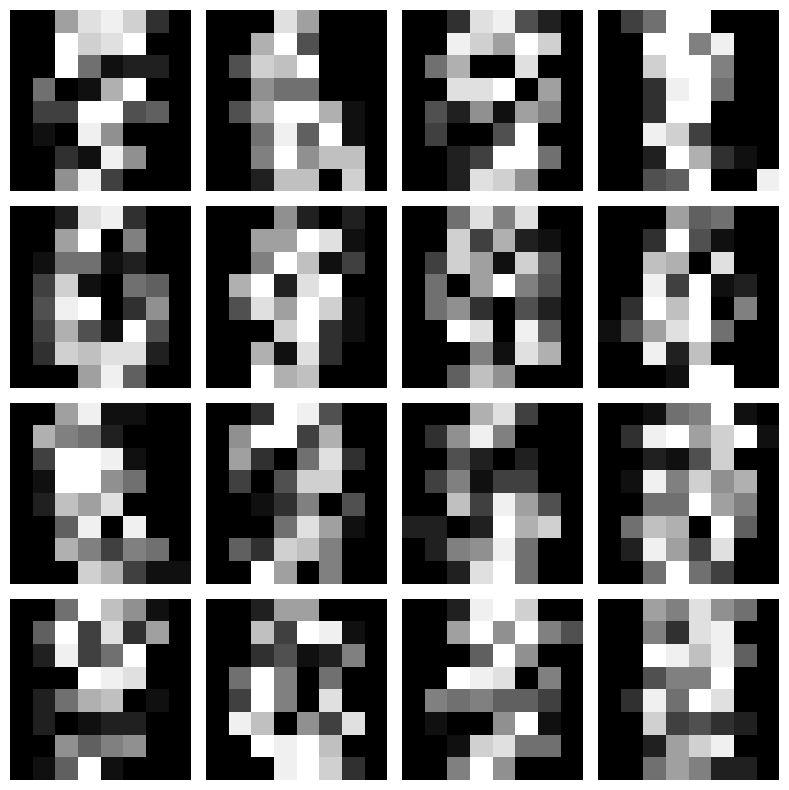

Epoch: 44, val nll=104.697353515625
saved!


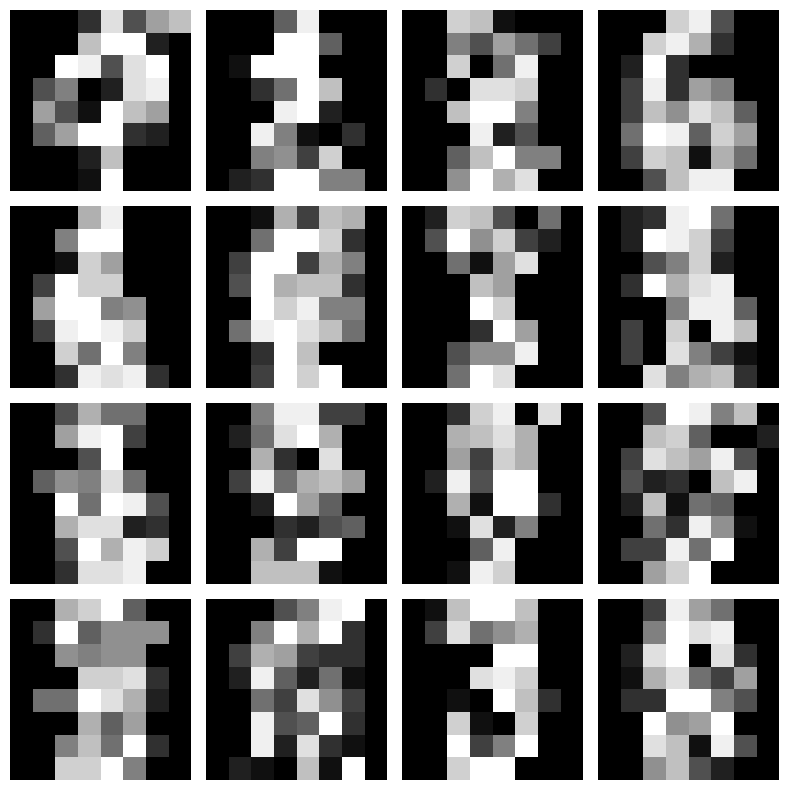

Epoch: 45, val nll=104.54675083705357
saved!


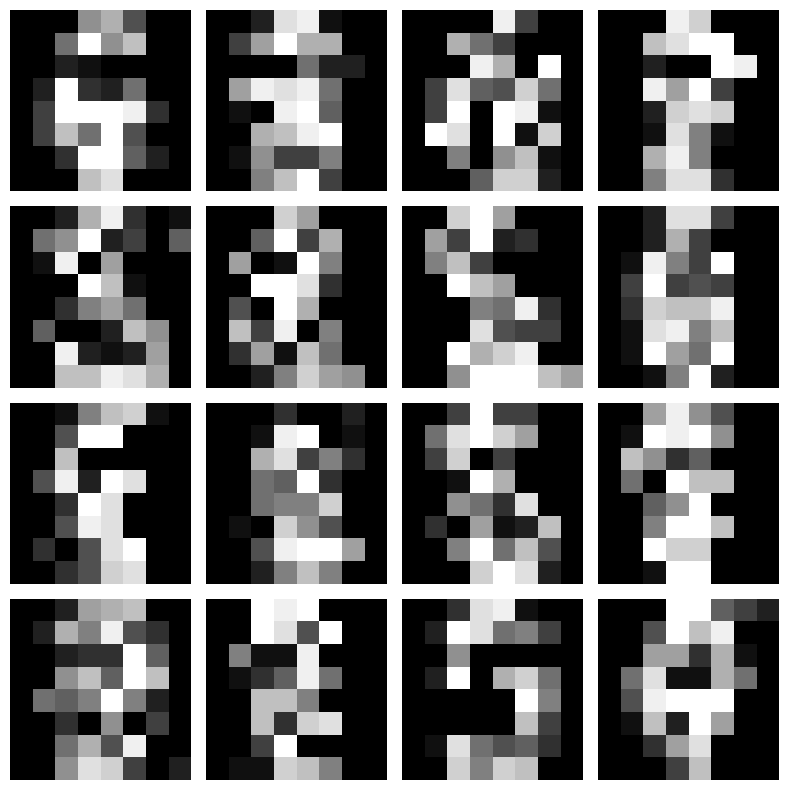

Epoch: 46, val nll=104.49639927455357
saved!


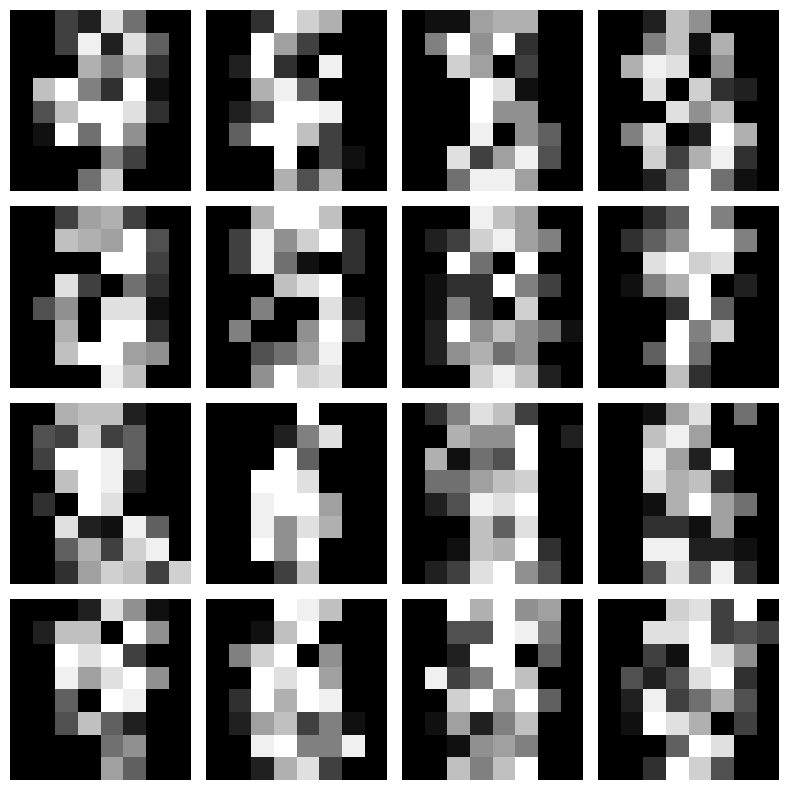

Epoch: 47, val nll=104.32252162388393
saved!


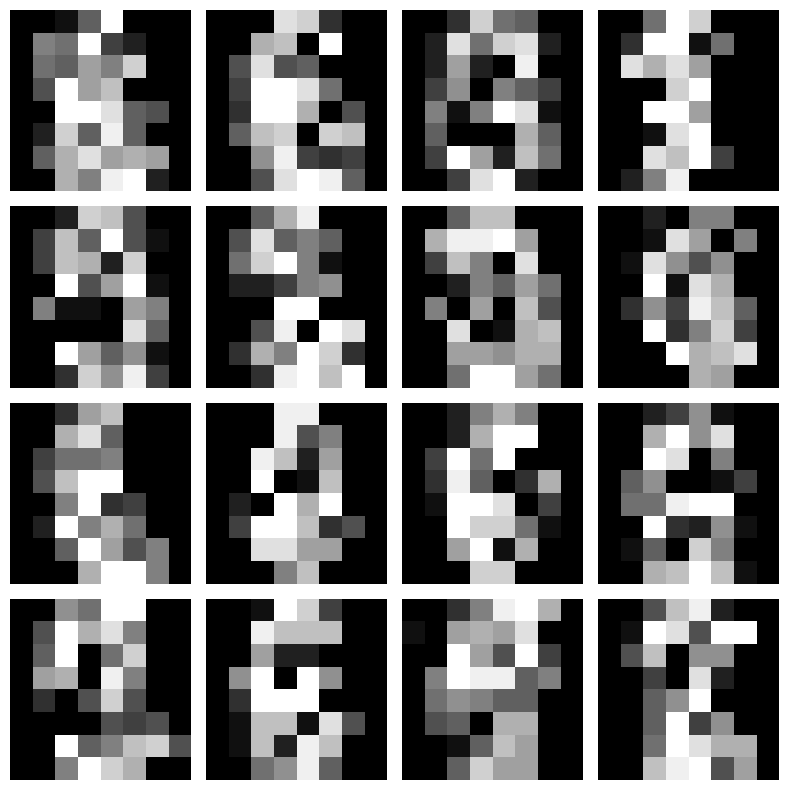

Epoch: 48, val nll=104.13523856026785
saved!


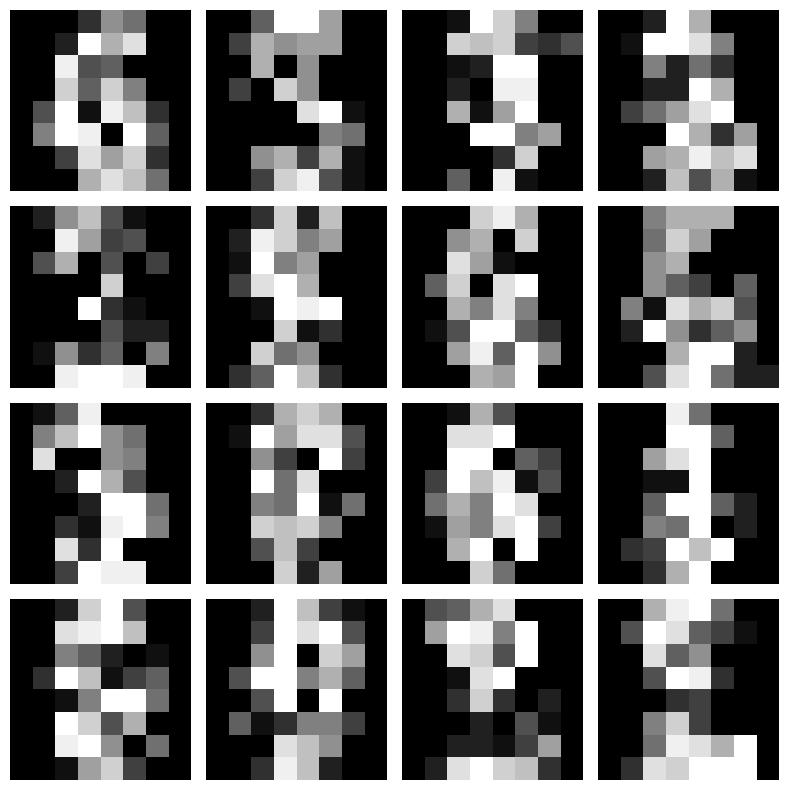

Epoch: 49, val nll=104.2065673828125
Epoch: 50, val nll=103.95582938058035
saved!


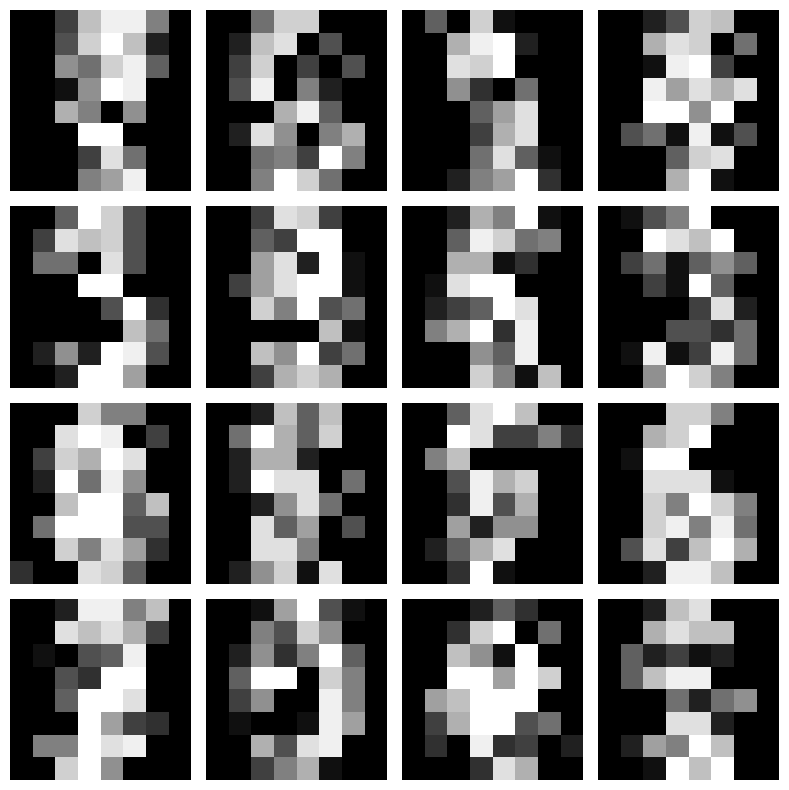

Epoch: 51, val nll=103.60662039620536
saved!


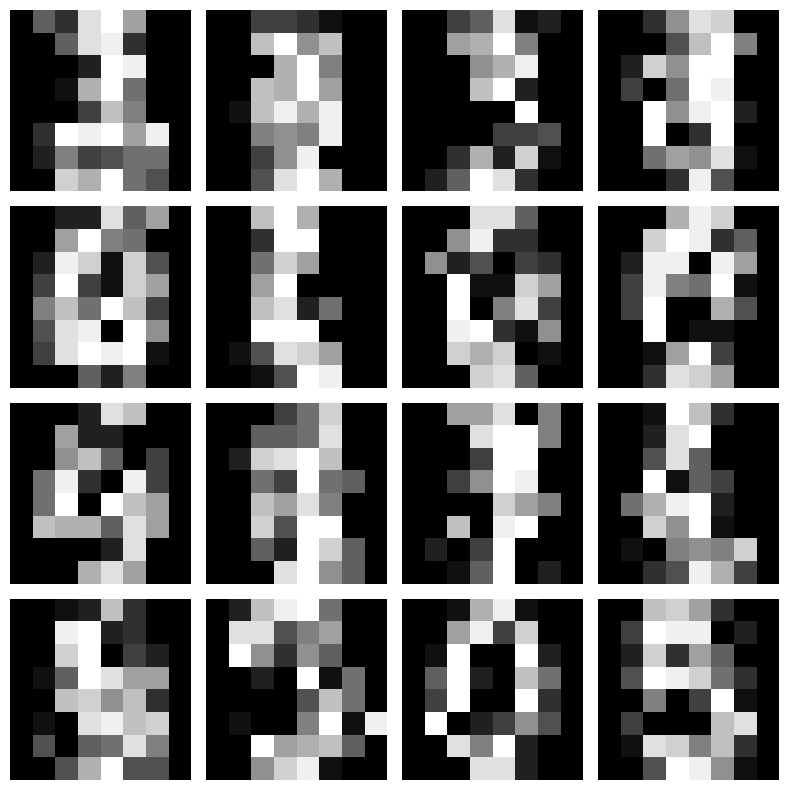

Epoch: 52, val nll=103.74938197544643
Epoch: 53, val nll=103.36023018973215
saved!


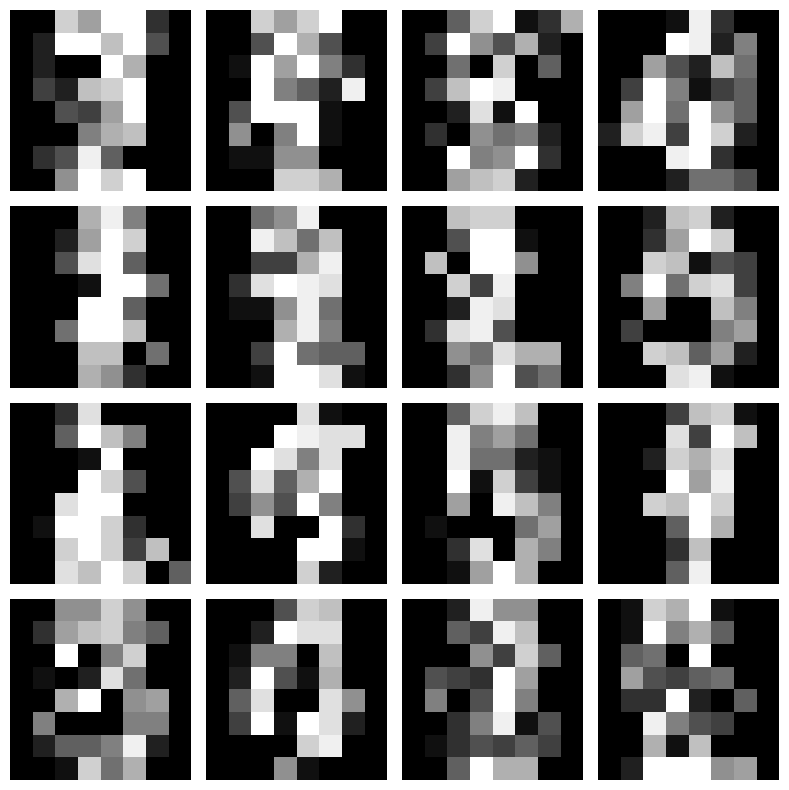

Epoch: 54, val nll=103.16549246651786
saved!


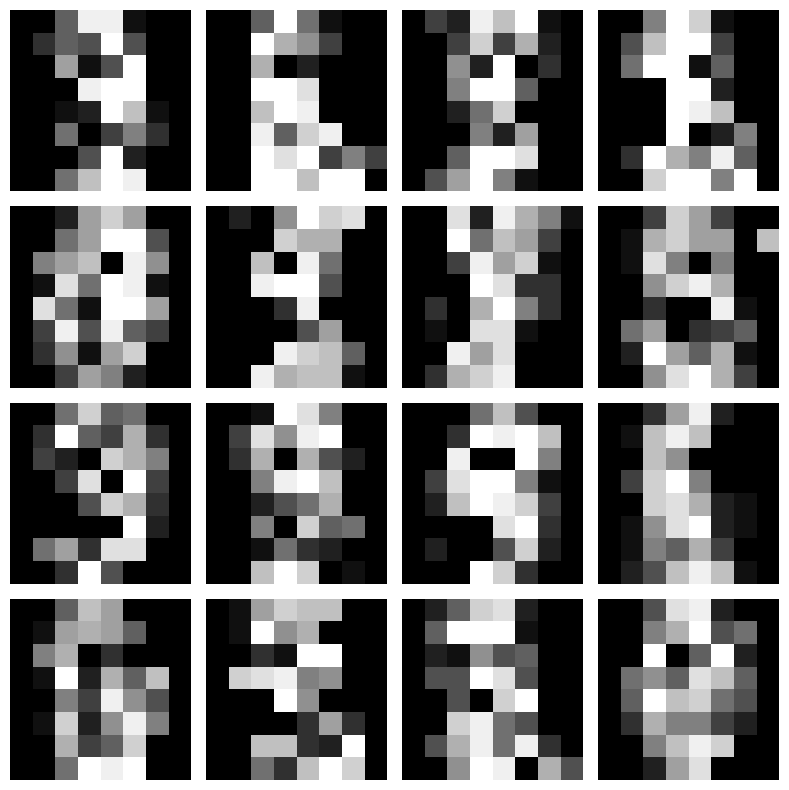

Epoch: 55, val nll=102.62003557477678
saved!


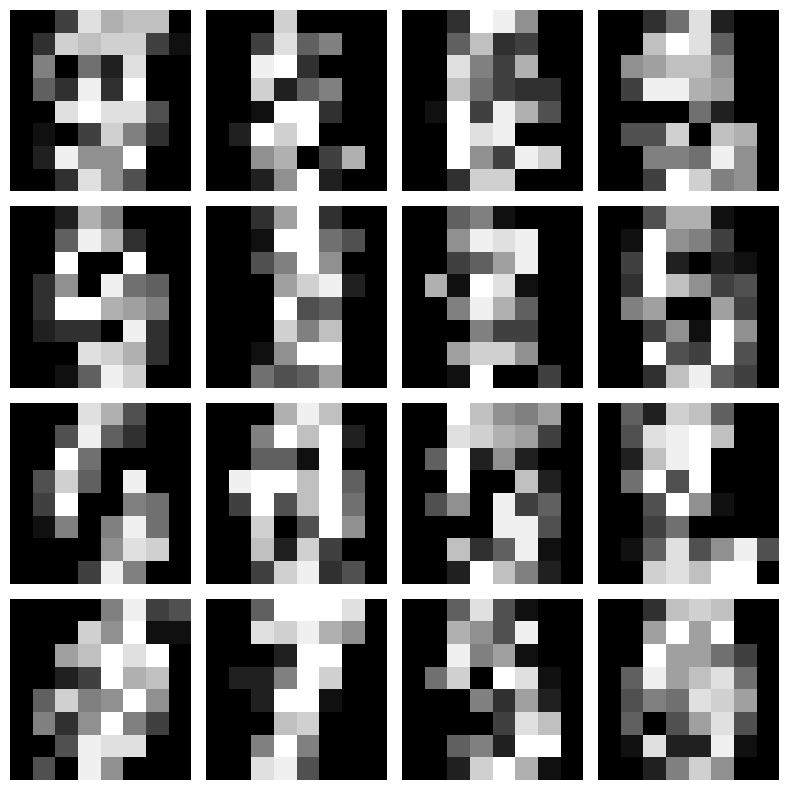

Epoch: 56, val nll=102.83166434151785
Epoch: 57, val nll=102.62816266741072
Epoch: 58, val nll=102.48006905691965
saved!


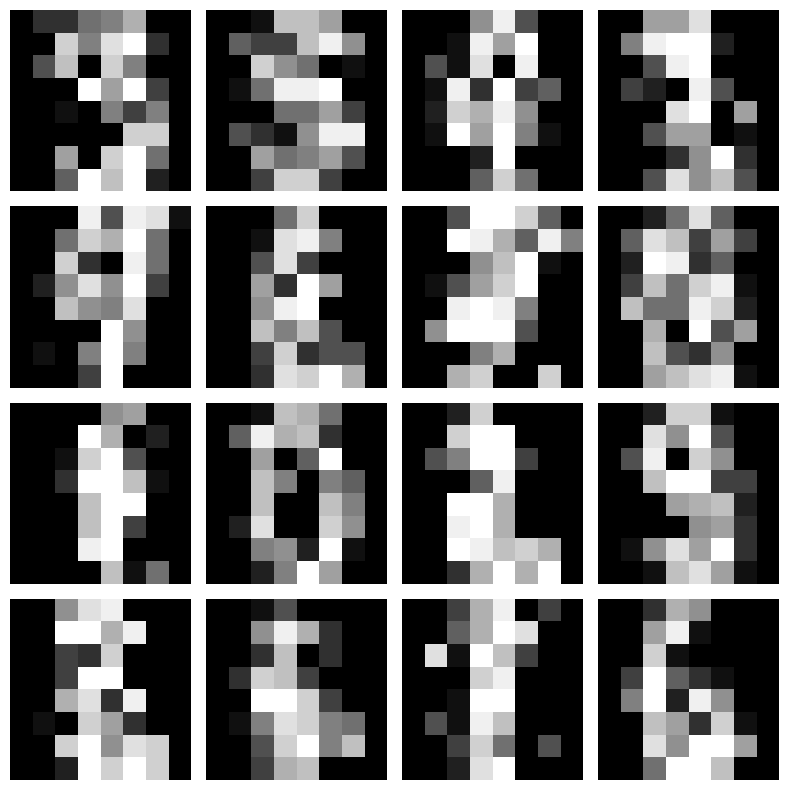

Epoch: 59, val nll=102.64934640066964
Epoch: 60, val nll=102.33815778459821
saved!


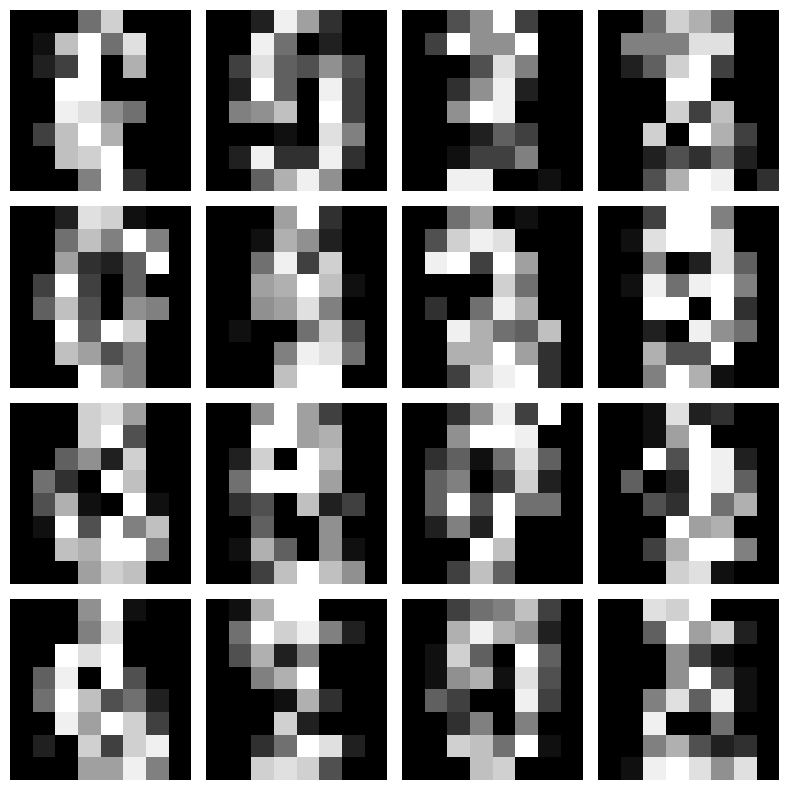

Epoch: 61, val nll=102.74485770089285
Epoch: 62, val nll=102.11227608816964
saved!


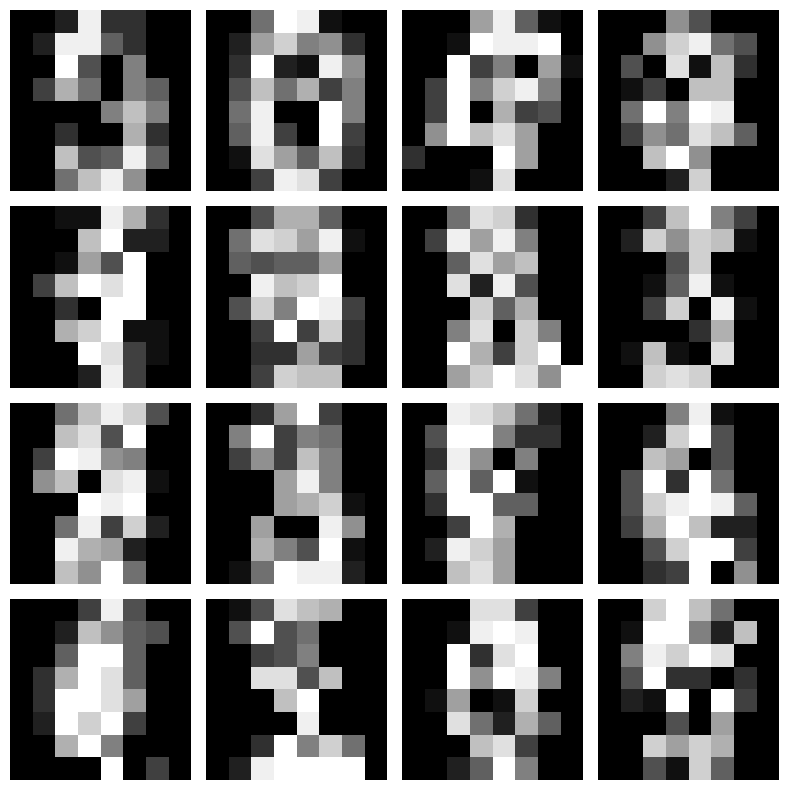

Epoch: 63, val nll=102.383994140625
Epoch: 64, val nll=102.28293736049108
Epoch: 65, val nll=102.10008440290179
saved!


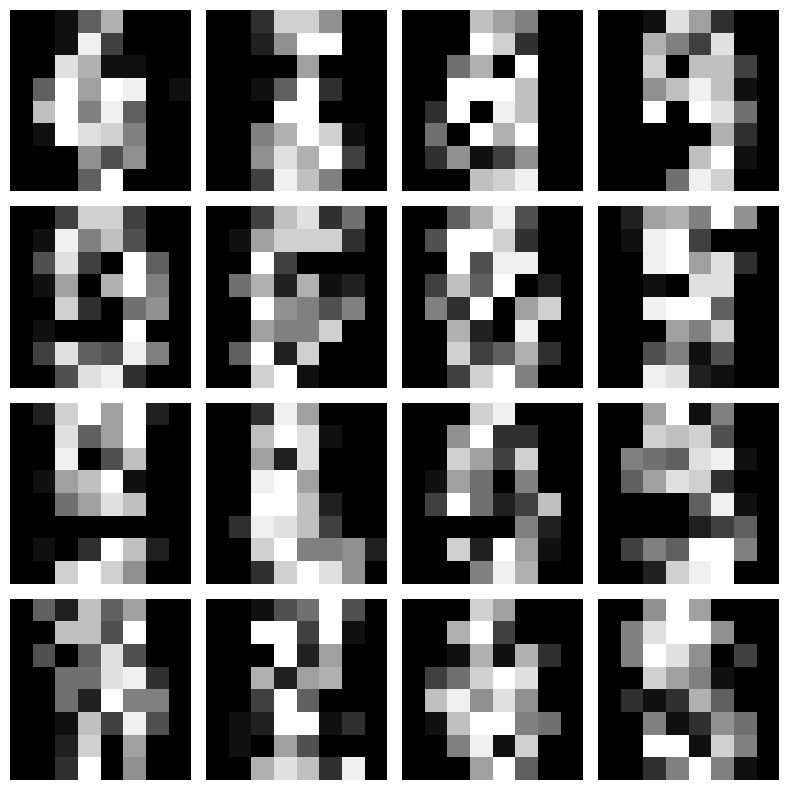

Epoch: 66, val nll=101.68818429129465
saved!


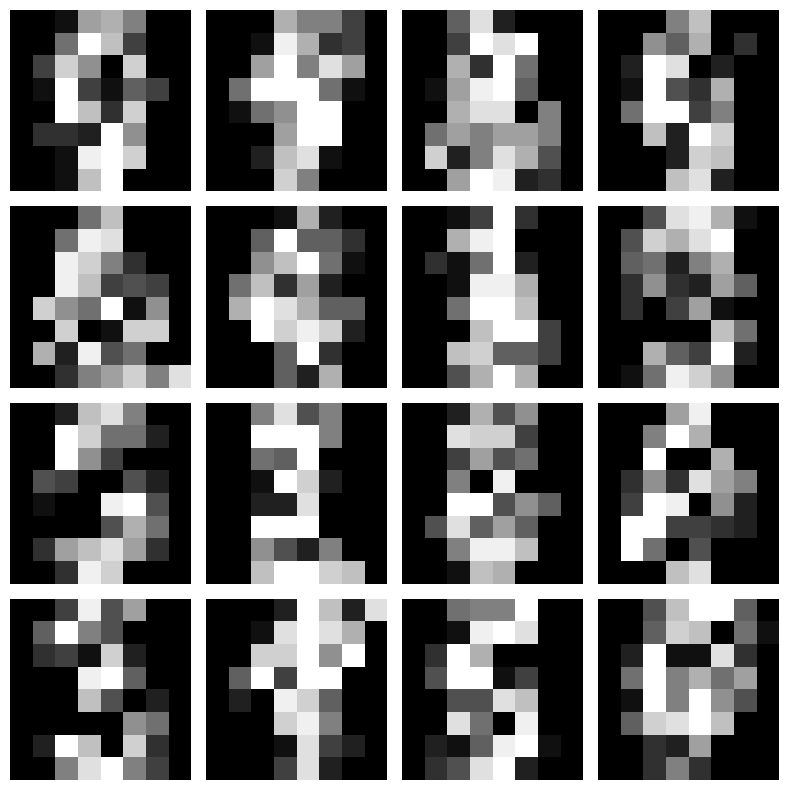

Epoch: 67, val nll=101.90884835379464
Epoch: 68, val nll=101.80169852120535
Epoch: 69, val nll=101.56221051897322
saved!


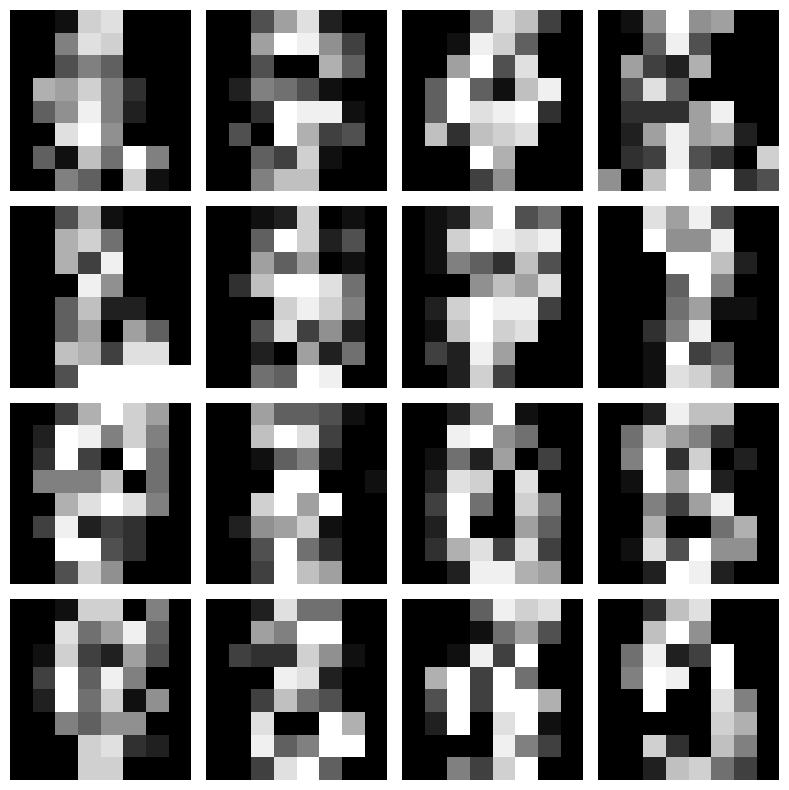

Epoch: 70, val nll=101.51055454799108
saved!


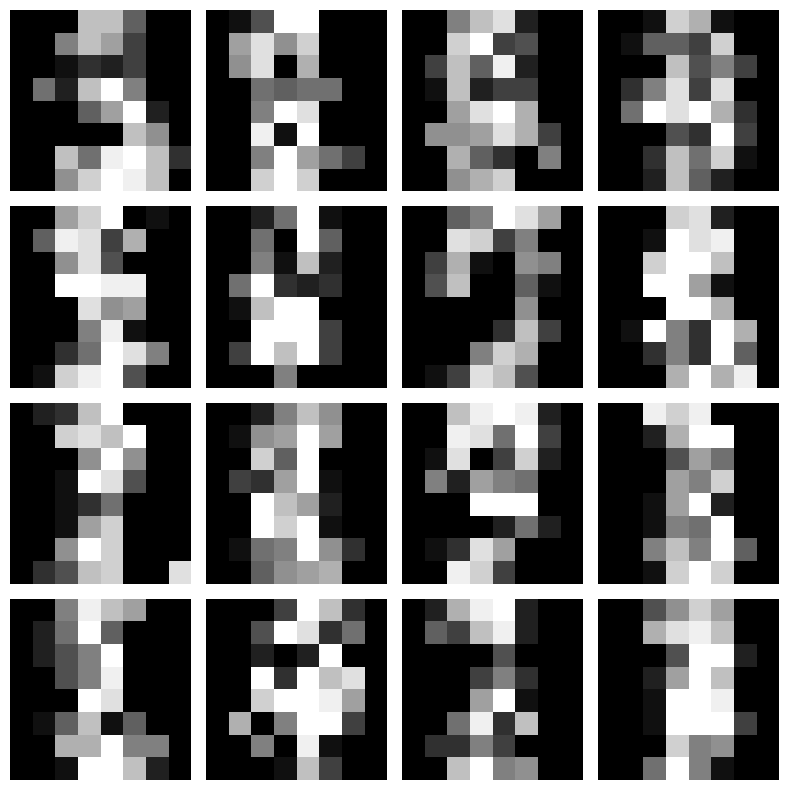

Epoch: 71, val nll=101.3833349609375
saved!


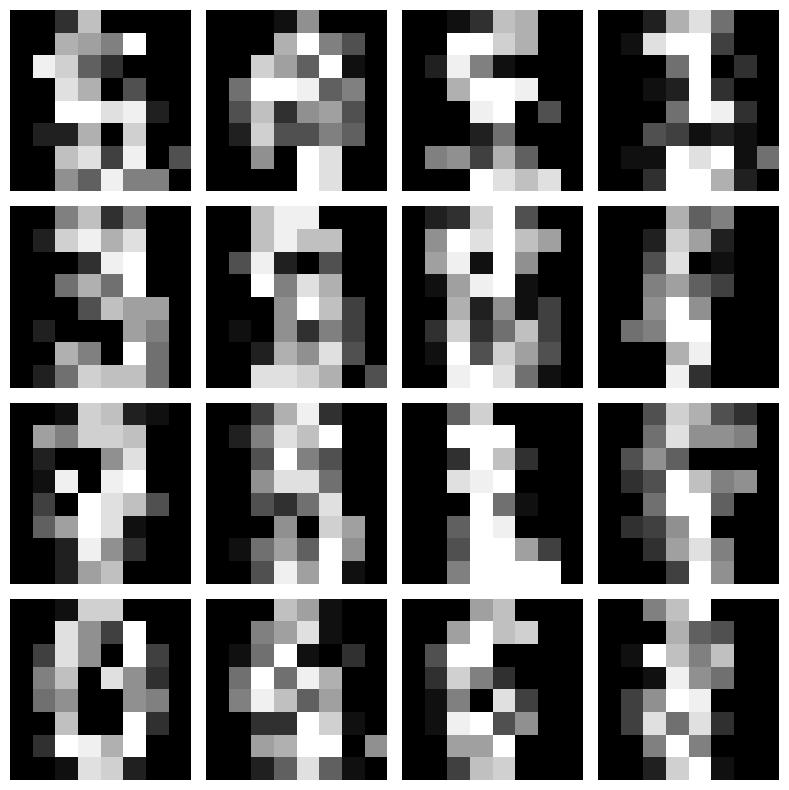

Epoch: 72, val nll=101.37166852678571
saved!


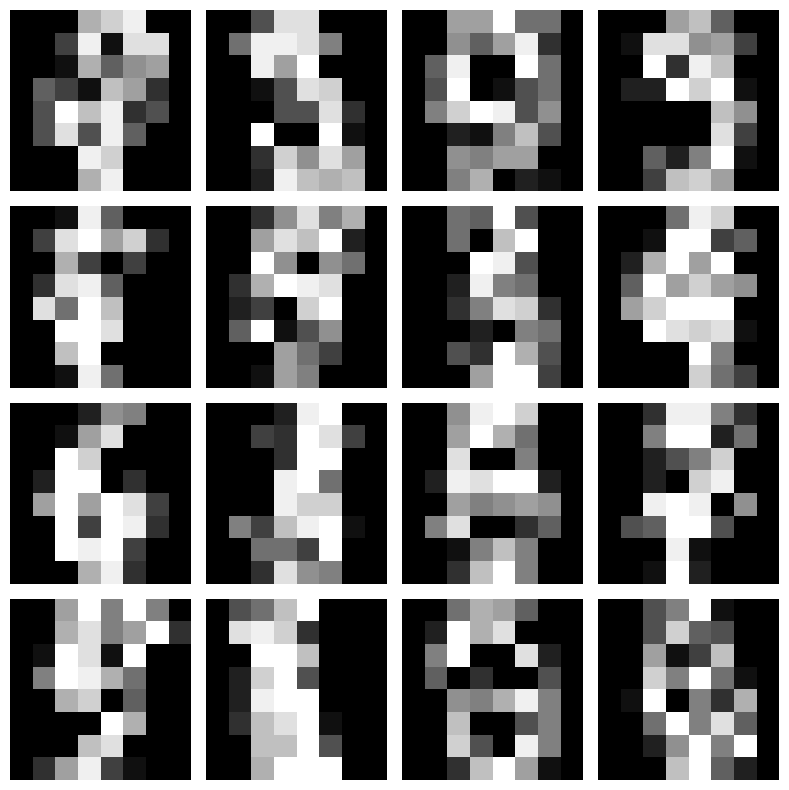

Epoch: 73, val nll=101.49753766741071
Epoch: 74, val nll=101.57138044084822
Epoch: 75, val nll=101.39805245535715
Epoch: 76, val nll=101.22986188616072
saved!


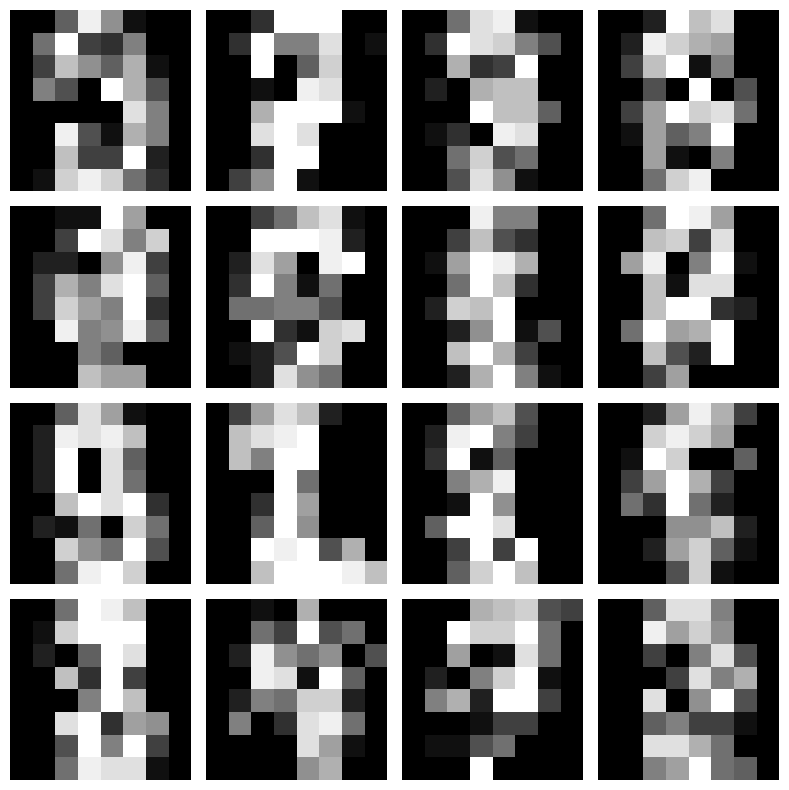

Epoch: 77, val nll=101.53416782924107
Epoch: 78, val nll=101.41828683035715
Epoch: 79, val nll=101.21567313058036
saved!


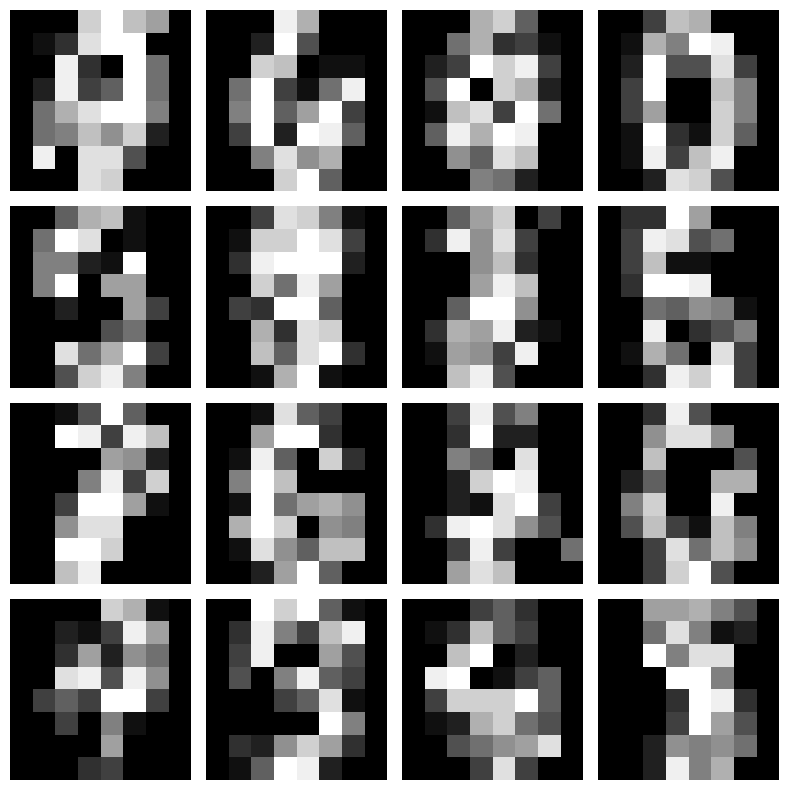

Epoch: 80, val nll=101.16548409598214
saved!


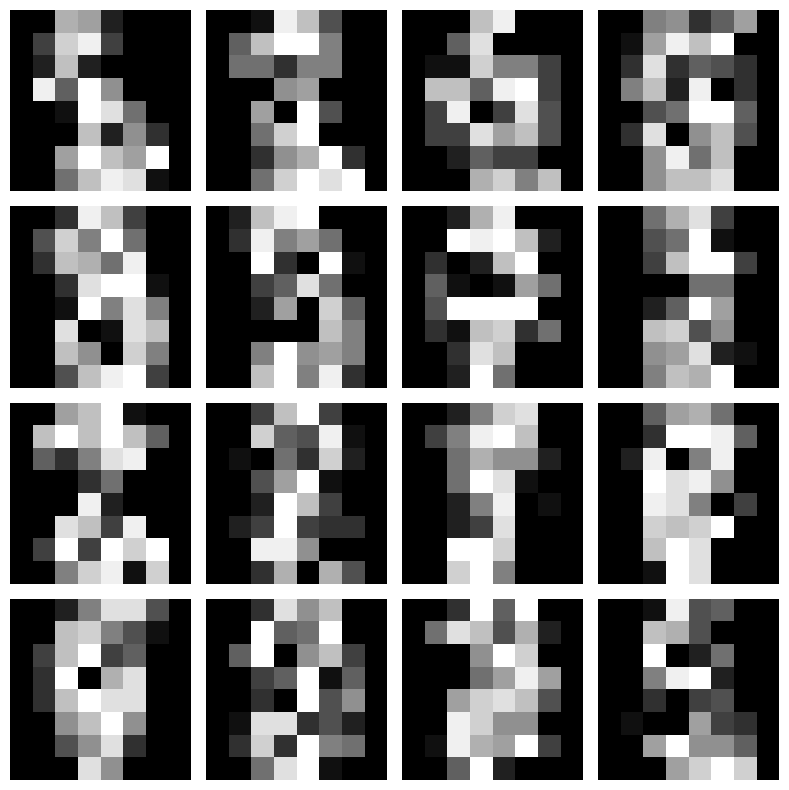

Epoch: 81, val nll=101.29320452008929
Epoch: 82, val nll=101.49648088727679
Epoch: 83, val nll=101.01739676339285
saved!


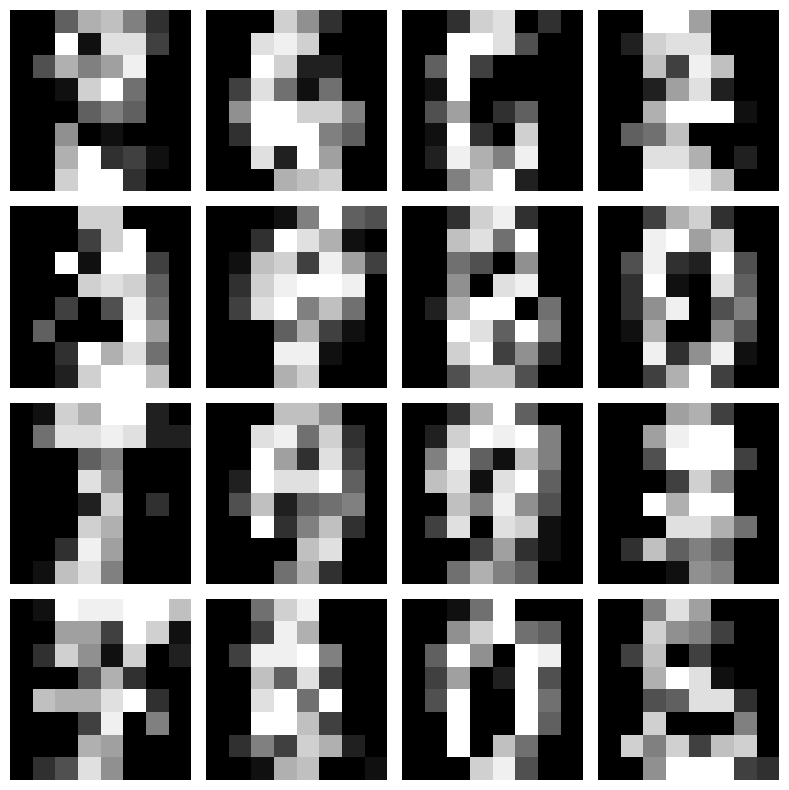

Epoch: 84, val nll=101.0878515625
Epoch: 85, val nll=101.15035505022321
Epoch: 86, val nll=100.77753348214286
saved!


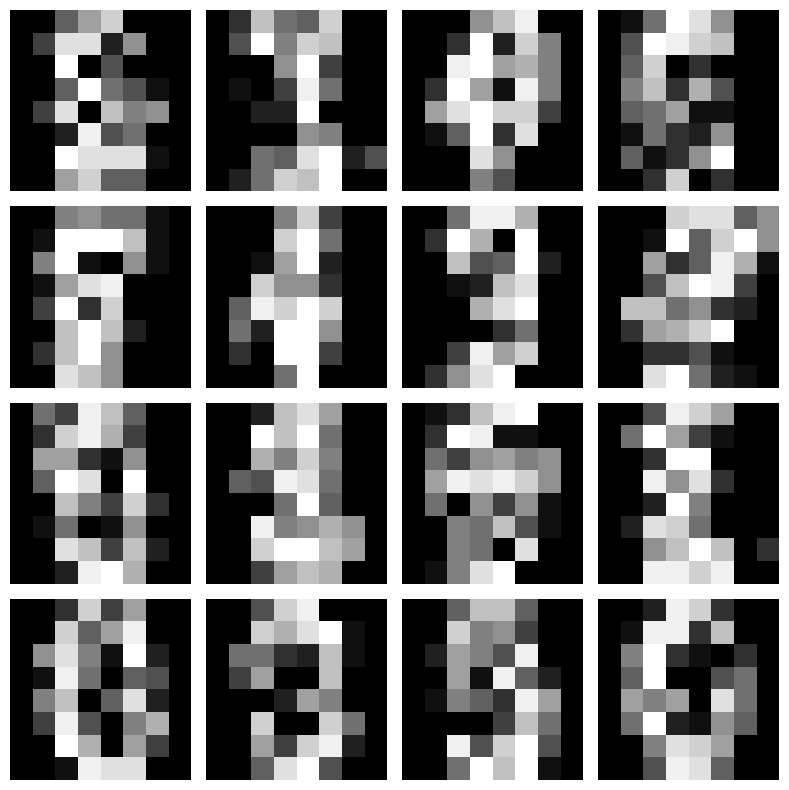

Epoch: 87, val nll=101.23644112723214
Epoch: 88, val nll=101.00162248883929
Epoch: 89, val nll=101.08482142857143
Epoch: 90, val nll=100.98260393415178
Epoch: 91, val nll=101.05556361607142
Epoch: 92, val nll=100.8525
Epoch: 93, val nll=100.91313197544643
Epoch: 94, val nll=100.84346261160714
Epoch: 95, val nll=101.24415736607143
Epoch: 96, val nll=100.95407505580357
Epoch: 97, val nll=100.781767578125
Epoch: 98, val nll=100.71426897321429
saved!


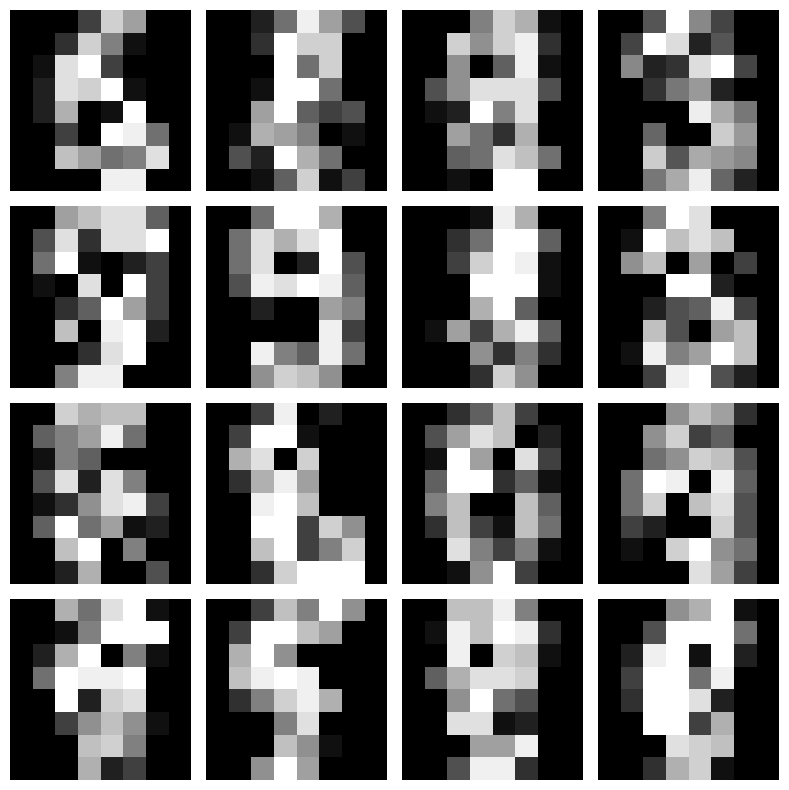

Epoch: 99, val nll=101.16823311941964
Epoch: 100, val nll=100.84209333147321
Epoch: 101, val nll=100.99124302455357
Epoch: 102, val nll=100.88672223772322
Epoch: 103, val nll=100.775673828125
Epoch: 104, val nll=100.87215192522322
Epoch: 105, val nll=101.1186083984375
Epoch: 106, val nll=100.94910435267857
Epoch: 107, val nll=101.00997000558036
Epoch: 108, val nll=101.05784946986607
Epoch: 109, val nll=101.24705984933036
Epoch: 110, val nll=101.39958914620536
Epoch: 111, val nll=100.68808942522321
saved!


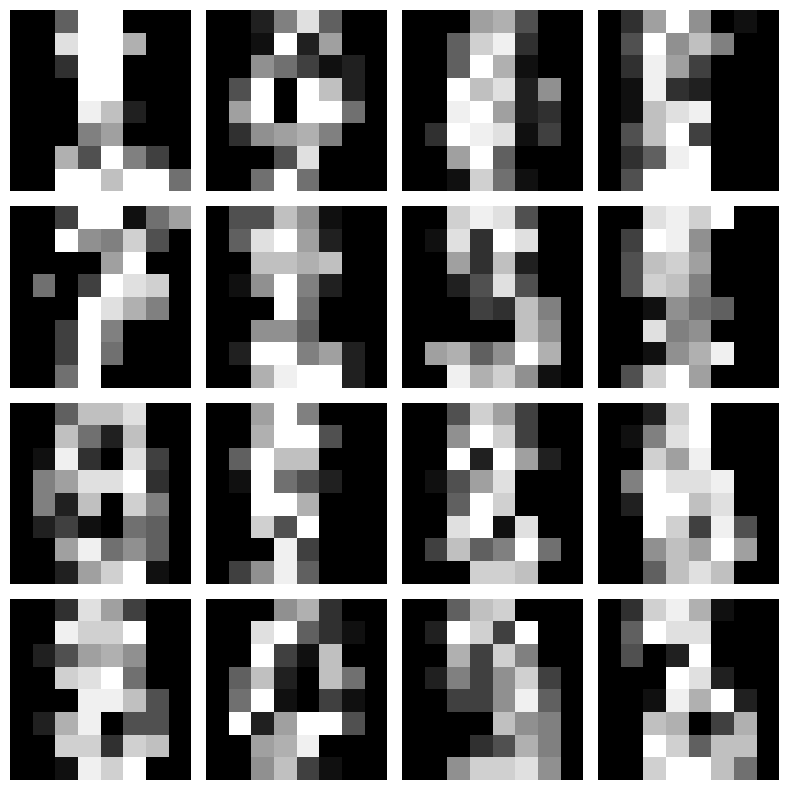

Epoch: 112, val nll=100.9423486328125
Epoch: 113, val nll=100.89919921875
Epoch: 114, val nll=101.47957310267857
Epoch: 115, val nll=100.767587890625
Epoch: 116, val nll=101.41561244419643
Epoch: 117, val nll=100.95613141741072
Epoch: 118, val nll=101.41789760044642
Epoch: 119, val nll=101.1393896484375
Epoch: 120, val nll=101.35099330357143
Epoch: 121, val nll=101.24826102120535
Epoch: 122, val nll=101.43188197544643
Epoch: 123, val nll=101.25171595982142
Epoch: 124, val nll=101.5190283203125
Epoch: 125, val nll=101.01674176897322
Epoch: 126, val nll=101.47106794084822
Epoch: 127, val nll=101.61949009486607
Epoch: 128, val nll=101.40064104352679
Epoch: 129, val nll=101.52671247209821
Epoch: 130, val nll=101.1260693359375
Epoch: 131, val nll=101.42668875558036
Epoch: 132, val nll=101.21995256696428


In [14]:
# Training procedure
nll_val = training(name=result_dir + name, max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                       training_loader=training_loader, val_loader=val_loader)

FINAL LOSS: nll=96.55684380243288
Test loss: 96.55684380243288


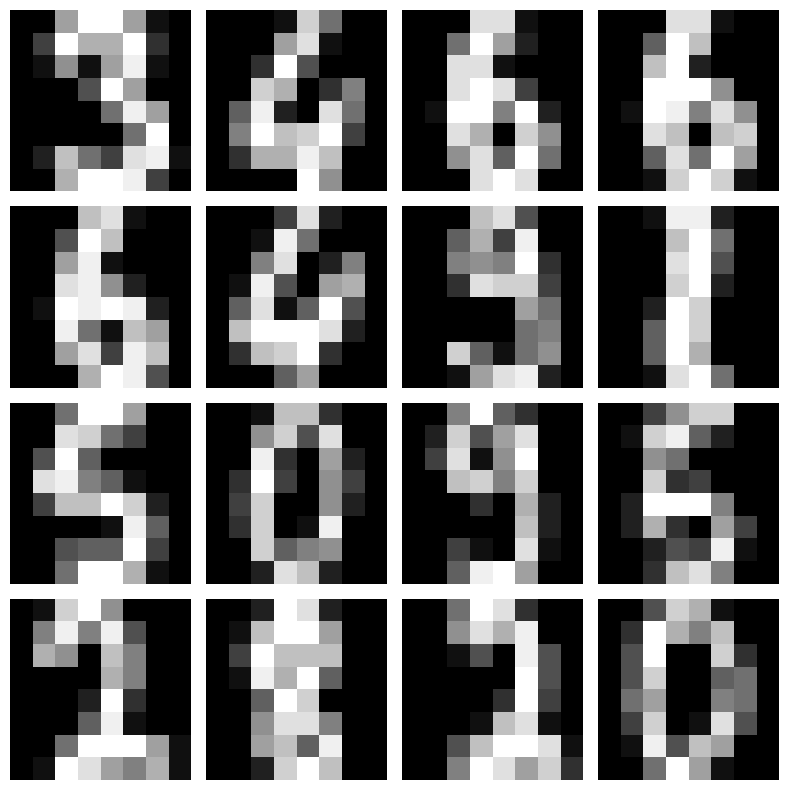

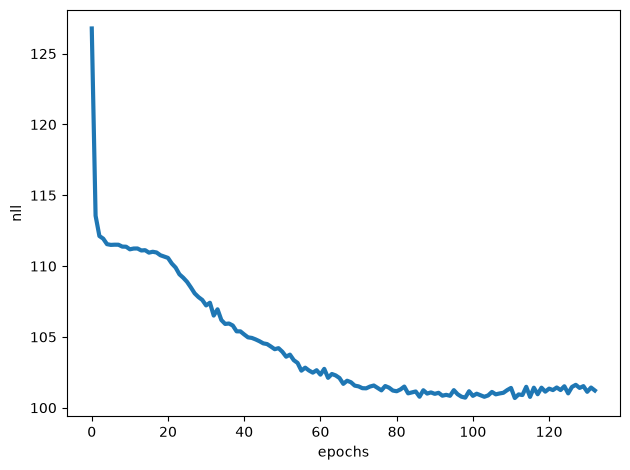

In [15]:
test_loss = evaluation(name=result_dir + name, test_loader=test_loader)
print(f"Test loss: {test_loss}")

samples_real(result_dir + name, test_loader)

plot_curve(result_dir + name, nll_val)
